# Stage 1: RNA and Protein Representation Analysis

This notebook investigates what pretrained nucleotide and protein models represent and how their representations relate to one another. The pilot uses nucleotide sequences and mRNA stability labels from `mRNA_Stability.csv`.

Each retained nucleotide sequence supplies two model inputs: its nucleotide sequence for Nucleotide Transformer and its translated amino acid sequence for ESM-2. Both encoders remain frozen during the analysis. Their parameters are not updated using the pilot dataset.

The protein input is derived by translation from the nucleotide input. The comparison therefore examines how two pretrained encoders represent related biological information.

## Research questions

- **Track A — Decodability:** Which properties can simple predictive models recover from the embeddings?
- **Track B — Cross-modal geometry:** How similarly do the two embedding spaces organize the same examples?
- **Track C — Attention analysis:** How does the selected attention summary relate to matches for RNA stability-associated sequence patterns?

## Role in the project

Stage 1 characterizes the representations available from the frozen encoders. Its observations inform the subsequent definition of alignment, development of fusion methods, and evaluation against single-modality baselines.

The analyses generate evidence and hypotheses for those later stages. Choosing an alignment objective or fusion architecture requires further controlled comparisons.

---

## Setup

### Imports

Imports are grouped by their role in the notebook.

In [2]:
# Standard library
import re

# Data handling and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

# Biological sequences and pretrained encoders
import torch
from Bio.Seq import Seq
from transformers import AutoModel, AutoTokenizer

# Statistical comparisons
from scipy.spatial.distance import pdist
from scipy.stats import mannwhitneyu, spearmanr

# Probes, dimensionality reduction, and evaluation
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupKFold, KFold, cross_val_score, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Analysis settings

These settings identify the input files, frozen encoders, and sample limits used in the pilot. Relative file paths assume the notebook runs with `Code` as its working directory.

`N_ROWS` controls the number of sampled rows before sequence filtering. The 1,000-row sample keeps the initial embedding workload manageable. Filtering can reduce the retained sample.

The encoder input limits are measured in tokens. The structural-proxy crop is measured in nucleotides.

`DEVICE` selects a CUDA GPU when available and otherwise uses the CPU. This affects execution time, particularly for embedding extraction and attention analysis.

In [3]:
SEED = 42
torch.manual_seed(SEED)

# Input files, relative to the Code directory
MAIN_CSV_PATH = "mRNA_Stability.csv"
CONTROL_CSV_PATH = "mRFP_Expression.csv"
SEQ_COLUMN = "Sequence"
LABEL_COLUMN = "Value"
LABEL_IS_CONTINUOUS = True

# Pilot sample size before sequence filtering
N_ROWS = 1000

# Frozen encoder checkpoints
RNA_MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"
PROTEIN_MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

# Maximum tokenized input lengths used for embedding extraction
RNA_MAX_LEN = 1000
PROTEIN_MAX_LEN = 1024

# Additional analysis limits
LAYERWISE_N_ROWS = 200
STRUCTURE_N_ROWS = 200
STRUCTURE_CROP_LEN = 200  # nucleotides

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


### Reproducibility

Sampling, stochastic analyses, and PyTorch initialization use `SEED`, currently set to `42`. Individual NumPy generators receive this seed when constructed.

PyTorch initialization is seeded before loading the encoders. Evaluation mode and disabled gradient tracking are handled when the encoders are loaded and used.

Reproducing an experiment also requires the same data, model revisions, package versions, and analysis settings. A fixed seed alone does not guarantee identical results across environments.

---

## Model loading and embedding functions

The two helpers below provide the same loading and embedding procedure for both encoders. `load_encoder` prepares a tokenizer and model for reuse; `embed` converts one sequence into a vector that later analyses can use.

### Loading an encoder

`load_encoder(name)` loads the tokenizer and pretrained encoder associated with the supplied model name. It moves the model to `DEVICE` and returns the tokenizer and model together. Defining this function does not load either encoder; the later loading cell calls it for each checkpoint.

`model.eval()` switches layers with distinct training and evaluation behavior, such as dropout, into evaluation mode. It does not disable gradient tracking or set the model's parameters to `requires_grad=False`. The separate `@torch.no_grad()` decorator on `embed` disables gradient tracking during embedding extraction, avoiding the memory cost of recording operations for a backward pass. The encoders remain unchanged because this workflow does not perform training updates. See the PyTorch documentation for [evaluation mode](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.eval) and [gradient tracking](https://docs.pytorch.org/docs/2.14/generated/torch.no_grad.html).

### Producing a sequence embedding

`embed(seq, tok, model, max_len)` tokenizes one sequence, moves the resulting input tensors to `DEVICE`, and runs the encoder. `truncation=True` limits the tokenized input to `max_len`. Token counts follow the model's tokenizer and need not equal the number of nucleotides or amino acids in the original sequence. This function processes one sequence at a time and does not request padding. See the Transformers documentation for [padding and truncation](https://huggingface.co/docs/transformers/main/en/pad_truncation).

The encoder returns a final hidden-state vector for each token. The `last_hidden_state` array has shape `(1, T, d)`: one sequence, `T` token positions, and `d` embedding features per position. This follows the Transformers [model-output convention](https://huggingface.co/docs/transformers/main_classes/output).

Mean pooling averages the token vectors to produce one vector for the sequence:

$$
\mathbf{z}
=
\frac{1}{T}
\sum_{t=1}^{T}
\mathbf{h}_{t}.
$$

In this notation:

- $T$ is the number of token positions returned after tokenization and truncation, including any special tokens.
- $t$ identifies one of those positions, from 1 through $T$ in the equation; tensor positions are indexed from 0 through `T - 1`.
- $\mathbf{h}_{t}$, read as "bold h sub t," is the final hidden-state vector at position $t$. Bold symbols represent vectors.
- $d$ is the number of features in each token vector and in the pooled sequence vector.
- $\mathbf{z}$ is the resulting sequence embedding.
- $\sum$ means to add the vectors across token positions. Dividing by $T$ takes their average, feature by feature.

For example, token vectors $(1, 3)$ and $(5, 7)$ would average to the sequence vector $(3, 5)$. This is an illustrative calculation, not a model output.

**Connection to the code.** The equation describes `token_embeddings.mean(dim=1)` inside `embed`; it is a direct average of the encoder output, not an additional fitted model. The surrounding operations prepare and return that vector.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `out.last_hidden_state` | Model output → `(1, T, d)` | Supplies the vectors $\mathbf h_t$ and retains the one-sequence batch axis. |
| `token_embeddings.mean(dim=1)` | `(1, T, d)` → `(1, d)` | Compute $\mathbf z$ by averaging over the token axis. |
| `.squeeze()` | `(1, d)` → `(d,)` | Remove the singleton batch axis for these encoder widths. |
| `.cpu().numpy()` | `(d,)` → `(d,)` | Return the vector as a NumPy array on the CPU. |

Sequences with different token counts therefore produce vectors of the same size for a given encoder. The pooled output no longer retains separate token positions.

### Current pooling choice

The mean includes every returned token position, including special tokens added by the tokenizer. The pooling operation does not use a separate mask to exclude positions. This documents the current representation definition; excluding special tokens or changing the weighting would change the embeddings and require a separate methodological decision.


In [4]:
def load_encoder(name):
    """Load a matching tokenizer and encoder on DEVICE in evaluation mode."""
    tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
    model = (
        AutoModel.from_pretrained(name, trust_remote_code=True)
        .to(DEVICE)
        .eval()
    )
    return tok, model


@torch.no_grad()
def embed(seq, tok, model, max_len=1024):
    """Mean-pool one sequence's final hidden state into a NumPy vector."""
    inputs = tok(
        seq,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(DEVICE)
    out = model(**inputs)

    token_embeddings = out.last_hidden_state  # (1, T, d)
    sequence_embedding = token_embeddings.mean(dim=1)  # (1, d)
    return sequence_embedding.squeeze().cpu().numpy()


## Sequence helper functions


These helpers prepare the two sequence forms used to build paired embeddings: a nucleotide sequence for the nucleotide encoder and an amino acid sequence for the protein encoder. The later dataset embedding function combines these operations and separately excludes translated proteins shorter than five amino acids.

### Checking the sequence length and start

`is_in_frame_and_starts_correctly(seq)` converts the string to uppercase, removes surrounding whitespace, and returns `True` only when its length is divisible by three and it begins with `ATG` or `AUG`. These are the DNA-letter and RNA-letter forms of the start codon accepted by this notebook.

Codons contain three nucleotides, so the length check is:

$$
L \bmod 3 = 0.
$$

In this notation:

- $L$ is the normalized string length, counted in nucleotide characters.
- $\bmod$ gives the remainder after integer division.
- The divisor 3 is the number of nucleotides per codon; a remainder of 0 means the length can be divided into complete groups of three.

**Connection to the code.** This equation is the Boolean test `len(seq) % 3 == 0` inside `is_in_frame_and_starts_correctly`; `%` is Python's remainder operator. The function combines that test with `seq.startswith(("ATG", "AUG"))` using `and`, so both must hold.

A 12-nucleotide sequence contains four complete codons and passes the length check; a 13-nucleotide sequence has one nucleotide left over and fails it. Passing the length check alone is insufficient: the starting letters must also match.

This is a preliminary filter. It does not validate the nucleotide alphabet, check for a terminal stop codon, or establish that the input is a complete biological coding sequence.

### Translating the sequence

`translate_cds(seq)` returns an amino acid string using Biopython's default standard genetic code. CDS stands for coding sequence. With `to_stop=True`, translation ends at the first in-frame stop codon, and the stop symbol is omitted. If there is no stop codon, all complete codons are translated. The call does not enable Biopython's separate `cds=True` validation. See the [Biopython translation documentation](https://biopython.org/docs/latest/api/Bio.Seq.html#Bio.Seq.Seq.translate).

Before translation, `len(seq) % 3` gives the number of trailing characters outside a complete codon. Subtracting that remainder identifies where to end the slice: an input of length 13 would be trimmed to length 12. In the current callers, surrounding whitespace has already been removed and the preceding length check requires a multiple of three, so this trimming normally removes nothing. It remains part of the helper's behavior when called independently.

### Converting RNA letters to DNA letters

`rna_to_dna(seq)` returns an uppercase string with every `U` replaced by `T`; for example, `AUGGCU` becomes `ATGGCT`. This changes the alphabet used to represent the nucleotide sequence. It does not translate the sequence into a protein or compute a complementary strand.

The notebook uses this DNA-letter form as input to the nucleotide encoder and in Track C's motif comparisons. Supporting both `ATG` and `AUG` in the initial check accommodates either input convention; it does not establish that both conventions occur in the CSV data.


In [5]:
def is_in_frame_and_starts_correctly(seq):
    """Check for a length divisible by three and an ATG or AUG start."""
    seq = seq.upper().strip()
    return len(seq) % 3 == 0 and seq.startswith(("ATG", "AUG"))


def translate_cds(seq):
    """Translate complete codons using the standard code, up to the first stop."""
    trimmed_seq = seq[: len(seq) - (len(seq) % 3)]
    return str(Seq(trimmed_seq).translate(to_stop=True))


def rna_to_dna(seq):
    """Return an uppercase sequence with U replaced by T."""
    return seq.upper().replace("U", "T")

def get_seqs_for_kept_rows(df, seq_col):
    """Return normalized nucleotide sequences in retained input order.

    Repeat the normalization and retention rules used during embedding.
    Moved up from the GC-content cell (2026-09-22) so it is available to
    every probe cell, for GroupKFold grouping by sequence identity.
    """
    kept = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            continue
        if len(translate_cds(seq)) < 5:
            continue

        kept.append(seq)

    return kept

## Linear probing and representation similarity


These functions support two parts of Stage 1. A linear probe tests whether a target can be predicted from an embedding with a simple fitted model. Linear centered kernel alignment (CKA) compares the similarity structure of two representations. The main inputs are embeddings already produced by the frozen encoders; `run_probe` also accepts simpler feature matrices, such as sequence length. Fitting a probe does not update the encoders.

### Linear probing

`run_probe(X, y, continuous, name, groups=None)` receives an embedding matrix `X` with shape `(n, p)` and a target array `y` with shape `(n,)`. There are `n` example rows and `p` features per row, and the targets must follow the same row order. `continuous` selects regression or classification, `name` labels the printed result, and `groups`, when supplied, gives one group identifier per row. The function evaluates the procedure and prints five-fold scores; it does not return a fitted model.

#### Standardization and model choice

**1. Estimate feature means and scales on the outer training rows.**

`StandardScaler` is inside `Pipeline([("scale", StandardScaler()), ("model", model)])`. Each outer fold fits its own scaler on that fold's training rows. For a finite feature, its training mean is:

$$
\mu_j = \frac{1}{m}\sum_{i\in\mathcal T}x_{ij}.
$$

In this notation:

- $X$ is the complete input matrix with shape $(n,p)$; $x_{ij}$ is its scalar entry in row $i$, feature column $j$.
- $i$ identifies an example, and $j$ identifies a feature from 1 through $p$. These equations count from 1; Python counts from 0.
- $\mathcal T$ is the set of row indices used for the current outer training fold; $i\in\mathcal T$ means that row $i$ belongs to that set.
- $m$ is the number of rows in $\mathcal T$.
- $\mu_j$, read as "mu sub j," is the mean of feature $j$ on those training rows.
- $\sum_{i\in\mathcal T}$ adds the indicated feature values over training rows. Dividing by $m$ takes their average.

For a feature with nonzero variance, the scale is:

$$
s_j = \sqrt{\frac{1}{m}\sum_{i\in\mathcal T}(x_{ij}-\mu_j)^2}.
$$

In this notation:

- $s_j$ is feature $j$'s training standard deviation. The subscript identifies a feature, not a fold.
- $x_{ij}-\mu_j$ is the feature value's deviation from its training mean; the exponent $2$ squares that deviation.
- $\sqrt{\phantom{x}}$ takes the square root after averaging the squared deviations.
- $m$, $\mathcal T$, $i$, $j$ and $\mu_j$ retain the meanings above. Dividing by $m$, rather than $m-1$, matches `StandardScaler`'s `ddof=0` convention.

**2. Apply those same training statistics to training and held-out rows.**

$$
z_{ij}=\frac{x_{ij}-\mu_j}{s_j}.
$$

In this notation:

- $z_{ij}$ is the standardized feature value for row $i$, column $j$; the standardized matrix has the same shape as its input subset.
- $x_{ij}$ may now come from a training row or a held-out row. In both cases, $\mu_j$ and $s_j$ come only from the outer training set.
- The division expresses the deviation in units of that feature's training standard deviation.

For example, training feature values `(2, 4)` give a mean of 3 and a scale of 1. A held-out value of 6 is then standardized to `(6 - 3) / 1 = 3`, using those same training statistics. These are illustrative values.

For a constant training feature, the scaler uses a scale factor of one instead of dividing by zero. These equations explain library operations performed by `StandardScaler`; the notebook does not implement separate loops for them. See [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

**3. Choose the model for the target.**

- A continuous target, such as a stability measurement, uses `RidgeCV(alphas=np.logspace(-3, 5, 20))` and is evaluated with $R^2$, defined below.
- A categorical target uses `LogisticRegression(max_iter=2000)` and is evaluated with accuracy: the fraction of held-out labels predicted correctly. The equations below describe the continuous-target branch; they are not the logistic-regression objective.

For a continuous target, a candidate ridge model predicts a weighted sum of standardized features plus an intercept:

$$
\hat y_i=\beta_0+\sum_{j=1}^{p}\beta_j z_{ij}.
$$

In this notation:

- $\hat y_i$, read as "y hat sub i," is the predicted target for example $i$; the hat distinguishes a prediction from the observed target $y_i$.
- $\beta_0$, read as "beta zero," is a scalar intercept.
- $\beta_j$ is the fitted coefficient multiplying standardized feature $j$.
- $p$ is the number of features, and $\sum_{j=1}^{p}$ adds their weighted contributions. The product $\beta_j z_{ij}$ is ordinary scalar multiplication.

For a fixed penalty strength, ridge regression balances training error against coefficient size:

$$
L_\alpha(\beta_0,\boldsymbol\beta)
=\sum_{i\in\mathcal T}(y_i-\hat y_i)^2
+\alpha\sum_{j=1}^{p}\beta_j^2.
$$

In this notation:

- $L_\alpha$ names the scalar objective at penalty strength $\alpha$; it is explanatory notation, not a function defined in this notebook.
- $\boldsymbol\beta=(\beta_1,\ldots,\beta_p)$ is the coefficient vector with shape $(p,)$. Bold type denotes a vector; the ellipsis means the intervening coefficients.
- $y_i-\hat y_i$ is the prediction error for training row $i$; the first sum adds its square over $\mathcal T$.
- $\alpha$, read as "alpha," is a positive scalar controlling the penalty. The second sum adds the squared feature coefficients and multiplies their total by $\alpha$.
- The intercept $\beta_0$ is not included in the penalty. Standardizing the features makes their scales comparable when penalizing their coefficients.

The fitted coefficients for that fixed penalty minimize this objective:

$$
(\beta_0^*,\boldsymbol\beta^*)
=\underset{\beta_0,\boldsymbol\beta}{\operatorname{argmin}}
L_\alpha(\beta_0,\boldsymbol\beta).
$$

In this notation:

- $\operatorname{argmin}$ means "choose the parameter values that make the objective smallest." It returns the intercept and coefficients, not the minimum objective value.
- The quantities below $\operatorname{argmin}$ identify the parameters being varied; $\alpha$ is held fixed in this equation.
- The superscript $*$ labels the selected parameters. It does not mean multiplication.

These are the [ridge regression objective](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and its mathematical minimization, performed inside scikit-learn. They are not a literal `argmin` call in `run_probe`. `RidgeCV` also chooses the penalty from the code's 20 candidates, evenly spaced on a logarithmic scale from $10^{-3}$ to $10^5$. ISLR calls this tuning parameter $\lambda$ ("lambda"); scikit-learn calls it `alpha`. ISLR, Sections 6.2.1 and 6.2.3, discuss scaling and selecting the penalty.

#### Evaluation and interpretation

**1. Hold out complete sequence groups for the outer evaluation.**

Every probe call below currently supplies `groups=kept_seqs`, or `groups=structure_groups` for the matching structure subsample. `GroupKFold(n_splits=5)` assigns each sequence group to exactly one held-out fold. Identical retained sequence strings therefore stay together across the outer train/test boundary. It needs at least five distinct groups and does not shuffle under the defaults used here. See [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html).

For each outer fold, `cross_val_score` fits the pipeline on the other four folds and evaluates its predictions on the held-out fold. Within that outer training subset, `RidgeCV` selects an alpha using its default efficient leave-one-out procedure, with negative mean squared error as its selection score. This internal model selection differs from the outer $R^2$ evaluation. See [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html).

The fallback `groups=None` branch uses `cross_val_score(..., cv=5)`. For the target types handled here, that means unshuffled `KFold` for regression or unshuffled `StratifiedKFold` for classification. This fallback does not enforce sequence groups. See [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

**2. Compare held-out regression errors with a mean-target reference.**

First find the held-out fold's observed target mean:

$$
\bar y_{\mathcal F}=\frac{1}{h}\sum_{i\in\mathcal F}y_i.
$$

In this notation:

- $\mathcal F$ is the set of held-out row indices for the current outer fold, and $h$ is its number of rows.
- $y_i$ is the observed target for held-out row $i$.
- $\bar y_{\mathcal F}$, read as "y bar for fold F," is the mean of those observed targets. The bar denotes an average.
- $\sum_{i\in\mathcal F}$ adds over held-out rows; division by $h$ gives the average.

For a fold whose targets vary, its score is:

$$
R^2=1-\frac{\sum_{i\in\mathcal F}(y_i-\hat y_i)^2}
{\sum_{i\in\mathcal F}(y_i-\bar y_{\mathcal F})^2}.
$$

In this notation:

- $R^2$ names the coefficient of determination; the superscript is part of its conventional name, not a direction to square an already calculated score.
- $\hat y_i$ is the prediction made without fitting on fold $\mathcal F$.
- The numerator adds squared prediction errors; the denominator adds squared errors for the reference that predicts the held-out mean $\bar y_{\mathcal F}$.
- Subtracting their ratio from one gives a score of one for perfect prediction and zero when the two error totals match.

The fold mean is used to define the score, not to train the model. A negative score means the model's errors exceed that reference error. Held-out $R^2$ can therefore be negative even though ISLR's introductory discussion considers a fitted least-squares model with an intercept. Constant targets require separate handling; see [scikit-learn's scoring documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html).

**3. Summarize the five outer scores.**

`scores.mean()` gives their arithmetic mean. `scores.std()` uses `ddof=0`, so it divides the sum of squared deviations by five before taking a square root. The printed `mean +/- standard deviation`, rounded to three decimals, describes variation across these folds. It is not a confidence interval or a standard error, and the mean gives each fold equal weight even if their row counts differ.

A probe assesses information accessible to this model under this evaluation procedure. A weak score alone does not establish that the embedding contains no useful information.

#### Current evaluation limitation

The current pipeline prevents outer held-out rows from setting the scaler statistics, and grouping prevents identical sequence strings from crossing the outer train/test boundary. The earlier implementation scaled all rows before splitting and did not keep repeated sequences together; those earlier limitations explain the historical labels below. See scikit-learn's [data-leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

The internal alpha-selection procedure has a narrower boundary: the scaler is fit once on the whole outer training subset before `RidgeCV` performs its internal leave-one-out calculation, and this code does not supply sequence groups to that internal calculation. This follows from the helper's ordering and the documented [Pipeline fitting sequence](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.fit). Thus preprocessing is not refit for each internal held-out row, and internal model selection is not grouped by sequence. Outer held-out rows remain excluded from fitting; the pipeline should not be described as refitting preprocessing and enforcing groups at every level of cross-validation. The numerical effect of changing the internal procedure has not been measured here.

The 2026-09-22 inventory recorded 65,356 CSV rows but 29,949 distinct sequences; 8,928 sequence groups occurred in more than one supplied `Split`. In the retained sample, 981 rows represented 964 distinct sequences, and 14 identical-sequence groups crossed the earlier five outer folds. These are dated inventory observations, not counts recalculated by this explanation. The current group policy addresses exact duplicate strings in the outer folds; it does not establish independence among related sequences. The cause of repetition, source-label mapping, and appropriate evaluation unit still need the provenance audit noted in the original explanation. No deduplication is performed by `run_probe`.

### Linear centered kernel alignment

`linear_cka(X, Y)` compares representations of the same examples. `X` has shape `(n, p)` and `Y` has shape `(n, q)`: their feature counts may differ, but corresponding rows must identify the same example. Capital `Y` here is a second embedding matrix, distinct from the lowercase probe target `y` above.

**1. Center each feature across examples.**

For feature $j$ of the first representation, calculate its mean:

$$
\bar x_j=\frac{1}{n}\sum_{i=1}^{n}x_{ij}.
$$

In this notation:

- $n$ is the shared number of example rows; $p$ and $q$ are the numbers of features in $X$ and $Y$, respectively.
- $x_{ij}$ is the scalar entry of $X$ in example row $i$, feature column $j$.
- $\bar x_j$ is the mean of that feature across all $n$ rows. The bar denotes an average.
- $\sum_{i=1}^{n}$ adds the feature values across rows; division by $n$ takes their average.

Subtract that mean from each value in the feature:

$$
(X_c)_{ij}=x_{ij}-\bar x_j.
$$

In this notation:

- $X_c$ is the centered matrix, still of shape $(n,p)$; the subscript $c$ labels centering.
- $(X_c)_{ij}$ selects its entry at row $i$, column $j$.
- $x_{ij}$ and $\bar x_j$ have the meanings above: each row loses the same mean for feature $j$.

The code applies the same two operations independently to `Y` to obtain $Y_c$, with shape $(n,q)$. It subtracts each representation's own column means. Unlike the probe's standardization, CKA centering does not divide by feature standard deviations.

**2. Measure feature dot-product matrices with the Frobenius norm.**

The Frobenius norm combines all entries of a matrix into a scalar size:

$$
\|A\|_F=\sqrt{\sum_{a=1}^{r}\sum_{b=1}^{s}A_{ab}^{\,2}}.
$$

In this notation:

- $A$ is any real-valued matrix of shape $(r,s)$, and $A_{ab}$ is its entry in row $a$, column $b$.
- $r$ and $s$ are its row and column counts; $a$ and $b$ index those entries.
- The two summations add over every row and column. The exponent $2$ squares each entry, and the square root converts the total to a norm.
- $\|\cdot\|_F$ names the Frobenius norm. The subscript $F$ identifies the norm; it does not denote an evaluation fold here.

For example, the matrix with rows $(1,2)$ and $(2,4)$ has norm $\sqrt{1^2+2^2+2^2+4^2}=5$. Its squared Frobenius norm is $25$. These are illustrative values, not encoder results. NumPy implements this matrix norm with `np.linalg.norm(..., ord="fro")`; see [NumPy's norm definition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).

**3. Normalize the cross-representation quantity.**

$$
\operatorname{CKA}(X,Y)
=\frac{\|Y_c^\top X_c\|_F^2}
{\|X_c^\top X_c\|_F\,\|Y_c^\top Y_c\|_F}.
$$

In this notation:

- $\operatorname{CKA}(X,Y)$ is the scalar linear CKA value returned by `linear_cka` for the two input matrices.
- $X_c$ and $Y_c$ are the centered matrices defined above.
- $\top$, written `.T` in NumPy, means transpose: exchange rows and columns.
- Juxtaposing matrices, as in $Y_c^\top X_c$, means matrix multiplication, written `@` in NumPy. Each output entry sums products along the shared dimension.
- $Y_c^\top X_c$ has shape $(q,p)$ and contains dot products between centered features in the two representations.
- $X_c^\top X_c$ has shape $(p,p)$, and $Y_c^\top Y_c$ has shape $(q,q)$. They contain feature dot products within each representation.
- $\|\cdot\|_F$ has the definition above. The numerator squares that norm; the denominator multiplies two unsquared scalar norms.

**Connection to the code.**

This is a direct NumPy calculation in `linear_cka`; no model is fitted. The table follows its operations in their actual order.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `X.mean(axis=0, keepdims=True)` | `(n, p)` → `(1, p)` | Calculate each feature mean $\bar x_j$, retaining a row dimension. |
| `X - X.mean(axis=0, keepdims=True)` | `(n, p)` → `(n, p)` | Subtract those means from every example to form $X_c$. The `Y` assignment similarly forms $Y_c$. |
| `Y_centered.T @ X_centered` | `(q, n)` and `(n, p)` → `(q, p)` | Form the cross-representation feature dot products. |
| `np.linalg.norm(..., ord="fro") ** 2` | `(q, p)` → scalar | Square their Frobenius norm to obtain `numerator`. |
| `X_centered.T @ X_centered`, then its Frobenius norm | `(p, n)` and `(n, p)` → `(p, p)` → scalar | Obtain `norm_x`; the corresponding `Y` operation gives `norm_y` through a `(q, q)` matrix. |
| `numerator / (norm_x * norm_y)` | Three scalars → scalar | Return the normalized CKA value. |

The `...` stands for the matrix product in the preceding row. NumPy broadcasts the `(1, p)` or `(1, q)` mean row during subtraction, applying it to every example row.

This feature-based calculation is equivalent to comparing the centered example-similarity matrices $X_cX_c^\top$ and $Y_cY_c^\top$, each of shape $(n,n)$. An entry in either matrix is the dot product between two centered example embeddings. The common normalization factor from the Hilbert-Schmidt independence criterion (HSIC) cancels in the CKA ratio, so the code names the unnormalized top term `numerator`.

For nonzero centered representations, linear CKA lies between zero and one in exact arithmetic. It is unchanged by orthogonal transformations, such as rotations and reflections, or by nonzero uniform scaling of either representation. Arbitrary changes of basis or separate scaling of individual features can change it. See [Kornblith et al. (2019), Section 3 and Table 1](https://proceedings.mlr.press/v97/kornblith19a/kornblith19a.pdf).

If either centered representation is entirely zero, the denominator is zero and CKA is undefined; this helper has no special handling for that case. High CKA describes representational similarity. It does not by itself establish good target prediction or a benefit from combining the modalities.

### Statistical and course references

- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning with Applications in R*, second edition: Section 3.1.3, p. 70 ($R^2$); Sections 5.1.2-5.1.3, pp. 200 and 203-204 (leave-one-out and k-fold cross-validation); Section 6.2.1, pp. 237-239 (ridge regression and scaling); Section 6.2.3, p. 250 (tuning). The original explanation records consultation of the local June 2023 corrected PDF. The [authors' book site](https://www.statlearning.com/) provides the book.
- UCF Machine Learning, *Week 04_Validation*, slides 5, 7, and 9: separating fitting, model selection, and evaluation, and rotating the held-out fold.
- UCF Machine Learning, *Data Preprocessing for Machine Learning*, slide 5: the role of feature scaling.
- UCF Capstone general lecture, *Overfitting and Regularization* (Yousefi, 2020), slides 19-20: the ridge penalty and selecting its strength by cross-validation.

The course decks provide explanatory context; linked library documentation explains the API behavior, and the code cell specifies the arguments passed here. CKA's definition comes from its research reference. Library documentation alone does not identify the environment or producing run of a saved result.

**Update (2026-09-22): preserved historical report.** The original update described moving `StandardScaler` inside a `Pipeline` and supplying sequence groups to all outer probe calls as fixing "both leaks." The current code has those two outer-evaluation changes; the internal-selection boundary is described above. The update reported the following values as verified against cached embeddings in `stage1_main_embeddings.npz` (981 rows, 964 distinct sequences). The numbers and their original before/after attribution are preserved here; this notation pass did not rerun that verification or reconstruct the producing runs.

| Probe | Reported old (leaky) R² | Reported fixed R² |
|---|---:|---:|
| RNA, stability | 0.059 ± 0.007 | 0.048 ± 0.034 |
| Protein, stability | 0.113 ± 0.066 | 0.115 ± 0.024 |
| Sequence length only | 0.007 ± 0.011 | 0.002 ± 0.014 |
| RNA, GC content | 0.986 ± 0.003 | 0.985 ± 0.001 |
| Protein, GC content | 0.681 ± 0.044 | 0.688 ± 0.016 |
| RNA, GC3 | 0.969 ± 0.004 | 0.970 ± 0.002 |
| Protein, GC3 | 0.379 ± 0.066 | 0.389 ± 0.038 |
| RNA, Nussinov structure | 0.103 ± 0.072 | 0.048 ± 0.102 |
| Protein, Nussinov structure | 0.078 ± 0.061 | 0.086 ± 0.122 |
| RNA + protein, concatenated | 0.115 ± 0.064 | 0.118 ± 0.029 |

**Unresolved saved-result discrepancy.** This historical table in cell `e38cbcc4` reports concatenated $R^2=0.118\pm0.029$, while saved stdout in code cell `065b7dfe` reports `0.100 +/- 0.048`. Both observations remain in the notebook. Their producing-run identities and cause of disagreement have not been established; neither value is selected as correct, and these two observations must not be treated as a verified before/after comparison.

The original update interpreted the composition scores as largely unchanged and concluded that concatenation showed "no real gain" over protein alone, motivating learned fusion. Its table does show similar composition means and a small reported difference between concatenation and protein stability means (0.118 versus 0.115). Its fold standard deviations do not all widen: some increase and others decrease. These descriptive comparisons do not establish statistical equivalence, absence of useful gain, or that a learned fusion method will improve prediction. The saved-result discrepancy further limits the conclusion. The structure section also preserves several result records whose association with the current method remains unresolved; see [Secondary-structure proxy: Nussinov pairing fraction](#Secondary-structure-proxy:-Nussinov-pairing-fraction). Learned fusion remains a candidate to evaluate, not a benefit established by these probe summaries.


In [ ]:
def run_probe(X, y, continuous, name, groups=None):
    """Print the mean and standard deviation of five linear-probe scores.

    2026-09-22 fix: standardization is now fit inside a Pipeline, so only
    each fold's training rows set the scaling statistics (previously
    StandardScaler was fit on all rows before cross-validation). When
    `groups` is supplied (the retained sequence strings), GroupKFold keeps
    every row from a duplicate-sequence group in the same fold, so the 14
    identical-sequence groups noted above can no longer cross folds. Falls
    back to plain KFold/StratifiedKFold when groups is None.
    """
    if continuous:
        model = RidgeCV(alphas=np.logspace(-3, 5, 20))
        scoring = "r2"
        metric_name = "R^2"
    else:
        model = LogisticRegression(max_iter=2000)
        scoring = "accuracy"
        metric_name = "accuracy"

    pipeline = Pipeline([("scale", StandardScaler()), ("model", model)])

    if groups is not None:
        cv = GroupKFold(n_splits=5)
        scores = cross_val_score(pipeline, X, y, cv=cv, groups=groups, scoring=scoring)
    else:
        scores = cross_val_score(pipeline, X, y, cv=5, scoring=scoring)

    print(
        f"  Linear probe on {name} embeddings, {metric_name} (5 fold): "
        f"{scores.mean():.3f} +/- {scores.std():.3f}"
    )

def linear_cka(X, Y):
    """Return linear CKA for representations with matching example rows."""
    X_centered = X - X.mean(axis=0, keepdims=True)
    Y_centered = Y - Y.mean(axis=0, keepdims=True)

    numerator = np.linalg.norm(Y_centered.T @ X_centered, ord="fro") ** 2
    norm_x = np.linalg.norm(X_centered.T @ X_centered, ord="fro")
    norm_y = np.linalg.norm(Y_centered.T @ Y_centered, ord="fro")
    return numerator / (norm_x * norm_y)


## Dataset embedding


The `embed_dataset` function turns rows of nucleotide sequences into paired nucleotide and protein embeddings. It is reused for the main dataset, where labels are requested, and the synonymous-recoding control, where the caller does not request labels.

The input DataFrame has already been loaded and sampled by the calling cell. This function processes its rows in their existing order, using the sequence helpers and embedding function defined above.

### From input rows to paired embeddings

For each row, the function:

1. Reads `seq_col` as a string, removes surrounding whitespace, and converts it to uppercase.
2. Applies the length/start check. A failing row is counted and skipped before translation.
3. Translates the sequence and skips it if the resulting protein has fewer than five amino acids. This rejection has its own counter.
4. Converts `U` to `T` for the nucleotide encoder and obtains its embedding using `RNA_MAX_LEN`.
5. Embeds the translated protein using `PROTEIN_MAX_LEN` and records the protein string.
6. Collects the row's label when `label_col` names an existing column.

Each retained row contributes one vector to each embedding list. The final `np.vstack` calls stack those vectors into matrices, with one row per retained example. The token limits remain the settings passed to `embed`; they do not change the sequence filters.

### Returned data and row correspondence

Each nonempty embedding matrix has one row per retained example and one column per embedding feature.

In this notation:

- $n$ is the number of retained examples.
- $d_{\mathrm{RNA}}$ and $d_{\mathrm{protein}}$ are the respective feature counts of the nucleotide and protein encoders. The subscripts identify the branch; these counts need not match.
- $i$ is a retained-row index, from 0 through `n - 1` in Python.

For $n > 0$, the return tuple contains:

| Position | Returned object | Shape or length |
|---|---|---|
| 1 | `rna_embeds`: nucleotide embedding matrix | `(n, d_RNA)` |
| 2 | `prot_embeds`: protein embedding matrix | `(n, d_protein)` |
| 3 | `protein_strings`: list of translated proteins | Length `n` |
| 4 | `labels`: target values, when collected | `(n,)` for scalar targets, or `None` when labels are not collected |

Row or list position $i$ in each returned object refers to the same retained input row. Filtering preserves the relative input order. The original DataFrame index is not included in the return tuple, so this correspondence is positional.

For example, if the middle row of three input rows is rejected, the two returned embedding matrices and the protein list contain the first and third examples in that order. The label array follows the same order when labels are collected.

### Rejection reporting and existing edge cases

The summary reports failed length/start checks separately from proteins shorter than five amino acids. These counts describe successive filters: a row that fails the first check is not translated or counted again. A summary is printed whenever either counter is nonzero.

If `label_col` is omitted or absent from the DataFrame, the function returns `None` for labels while still producing embeddings. When the column exists, retained label values are copied without additional validation; missing target values can therefore remain in the returned array.

If no rows survive, the current interface returns two empty NumPy arrays with shape `(0,)`, an empty protein list, and `None` for labels. The usual matrix shapes in the table apply only when at least one row is retained.


In [7]:
def embed_dataset(
    df, rna_tok, rna_model, prot_tok, prot_model, seq_col, label_col=None
):
    """Embed retained rows from seq_col and optionally collect label_col.

    Return RNA embeddings, protein embeddings, protein strings, and labels,
    with corresponding entries in retained input order. Labels are None
    when none are collected.
    """
    rna_vectors = []
    protein_vectors = []
    protein_strings = []
    label_values = []
    collect_labels = label_col is not None and label_col in df.columns

    dropped_sequence_check = 0
    dropped_short_protein = 0

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            dropped_sequence_check += 1
            continue

        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            dropped_short_protein += 1
            continue

        rna_vectors.append(
            embed(rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN)
        )
        protein_vectors.append(
            embed(protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN)
        )
        protein_strings.append(protein_seq)

        if collect_labels:
            label_values.append(row[label_col])

    if dropped_sequence_check or dropped_short_protein:
        print(
            f"  Dropped sequences: {dropped_sequence_check} failed length/start checks; "
            f"{dropped_short_protein} translated to fewer than 5 amino acids."
        )

    rna_embeds = np.vstack(rna_vectors) if rna_vectors else np.empty((0,))
    prot_embeds = np.vstack(protein_vectors) if protein_vectors else np.empty((0,))
    labels = np.array(label_values) if label_values else None
    return rna_embeds, prot_embeds, protein_strings, labels


---

## Load the encoders


The cell below calls `load_encoder` for each checkpoint selected in Setup. Each call returns a tokenizer and its matching model, which are retained for the later embedding cells.

| Configuration setting | Returned objects | Role |
|---|---|---|
| `RNA_MODEL_NAME` | `rna_tok`, `rna_model` | Tokenizer and encoder for the nucleotide-sequence branch. |
| `PROTEIN_MODEL_NAME` | `prot_tok`, `prot_model` | Tokenizer and encoder for the translated-protein branch. |

The `rna_*` names identify the nucleotide branch used for the source sequences; those sequences are converted to DNA letters before embedding. The shared `load_encoder` helper places each model on `DEVICE` and sets evaluation mode, as explained in the earlier helper section.

Loading may download tokenizer and checkpoint files from Hugging Face. Matching files already in the local cache can be reused, although model initialization and transfer to `DEVICE` still take time. See the Transformers [cache documentation](https://huggingface.co/docs/transformers/installation#cache-directory).

This cell prepares both tokenizer/model pairs. Sequence embedding occurs in the following section.


In [ ]:
rna_tok, rna_model = load_encoder(RNA_MODEL_NAME)
prot_tok, prot_model = load_encoder(PROTEIN_MODEL_NAME)
print("Encoders loaded.")

c:\Users\dimar\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dimar\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.94GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

### Interpreting the loading messages

The saved output in the [original notebook](Stage1.ipynb) records the following statuses for both checkpoints. This describes that earlier run; it does not substitute for inspecting the messages from a new run.

| Parameter names in the saved report | Status | Interpretation |
|---|---|---|
| `lm_head.*` | `UNEXPECTED` | The checkpoint contains language-modeling prediction-head weights that the loaded base encoder does not use. |
| `pooler.dense.weight` and `pooler.dense.bias` | `MISSING` | The instantiated model expects these pooler parameters, but they are absent from the checkpoint and were newly initialized. |

These messages describe different situations: unused checkpoint weights and model parameters initialized without checkpoint values. See the Transformers [loading-warning definitions](https://huggingface.co/docs/transformers/main_classes/model).

The `embed` helper computes its own mean over `last_hidden_state`. It does not use the model's separate `pooler_output`, and the base encoder does not use the listed language-modeling head weights. This explains why those particular head and pooler messages do not identify missing weights in the hidden-state path used to produce these embeddings. See the [ESM output definitions](https://huggingface.co/docs/transformers/main/en/model_doc/esm).

Any additional missing or unexpected parameters need to be interpreted against the model components actually used. The explanation above applies to the listed parameters and this embedding procedure.

The final `Encoders loaded.` message is printed after both calls to `load_encoder` return. It confirms completion of those loading calls; successful embedding extraction and downstream analysis must be checked separately.


## Embed the main dataset (mRNA_Stability)


This cell creates the paired embeddings and stability labels used by the main-dataset analyses. It uses the tokenizer/model pairs loaded above and the shared `embed_dataset` helper.

The pipeline is:

1. Load `MAIN_CSV_PATH` and drop rows missing a value in `SEQ_COLUMN`.
2. Sample `N_ROWS` rows without replacement using `SEED`. The current setting requests 1,000 rows before the helper applies its sequence filters. With the same input rows, row order, and software environment, the seed makes this sample repeatable. See the [pandas sampling documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).
3. Pass the sampled rows to `embed_dataset`, which applies the length/start and minimum protein-length checks described above. Retained rows produce `rna_embeds`, `prot_embeds`, and labels from `LABEL_COLUMN` in corresponding order. The returned protein strings are assigned to `_` and are not used in this section.
4. Report how many sampled rows were embedded and reconstruct `kept_seqs` with `get_seqs_for_kept_rows`, applying the same normalization and filters. Its strings identify exact-sequence groups for the probes.
5. Save the embedding and label arrays.

`main_df` remains the sampled DataFrame, including rows subsequently rejected by the helper. The embedding arrays contain only retained rows, so they can be shorter than `main_df`. This sampling step does not use the CSV's `Split` column; it does not establish separate training, validation, or test sets.

The `np.savez` call writes `stage1_main_embeddings.npz` in the current working directory with three keys: `rna`, `protein`, and `labels`. If no labels were collected, the saved `labels` entry is an empty array. Protein strings are not saved. This notebook has no cache-loading branch: rerunning the cell performs embedding again and overwrites the archive. The saved arrays could be loaded separately for later work. See the [NumPy archive documentation](https://numpy.org/doc/stable/reference/generated/numpy.savez.html).


In [ ]:
main_df = (
    pd.read_csv(MAIN_CSV_PATH)
    .dropna(subset=[SEQ_COLUMN])
    .sample(n=N_ROWS, random_state=SEED)
)
rna_embeds, prot_embeds, _, labels = embed_dataset(
    main_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN, LABEL_COLUMN
)
print(f"Embedded {len(rna_embeds)} of {len(main_df)} sampled sequences.")

# 2026-09-22: computed here (moved up from the GC-content cell) so every
# probe below can pass it to run_probe as the GroupKFold grouping key.
kept_seqs = get_seqs_for_kept_rows(main_df, SEQ_COLUMN)

np.savez(
    "stage1_main_embeddings.npz",
    rna=rna_embeds,
    protein=prot_embeds,
    labels=labels if labels is not None else np.array([]),
)


  Dropped sequences: 19 failed length/start checks; 0 translated to fewer than 5 amino acids.
Embedded 981 of 1000 sampled sequences.


### Inspect the output shapes

The following cell prints the dimensions of the arrays just produced. When at least one row is retained, each embedding shape is `(retained rows, embedding width)`, and the scalar stability labels should have shape `(retained rows,)`. A label shape of `None` means the helper did not collect labels. If no rows survive, the helper's existing empty-array behavior is described in the dataset-embedding section above.

These prints support manual inspection; they do not assert expected widths, verify row correspondence, or check label completeness and finite values. Matching dimensions alone do not establish that the encoders or resulting representations are suitable for the research question.


In [ ]:
print("RNA embedding shape:", rna_embeds.shape)
print("Protein embedding shape:", prot_embeds.shape)
print("Label shape:", labels.shape if labels is not None else None)


RNA embedding shape: (981, 1280)
Protein embedding shape: (981, 480)
Label shape: (981,)


### Historical output from the original run

The saved outputs in [the original notebook](Stage1.ipynb) report **981 embedded sequences out of 1,000 sampled rows**, a retention rate of **98.1%**. They show the following embedding shapes:

| Representation | Retained rows | Embedding width | Array shape |
|---|---:|---:|---|
| Nucleotide Transformer (`rna_embeds`) | 981 | 1,280 | `(981, 1280)` |
| ESM-2 (`prot_embeds`) | 981 | 480 | `(981, 480)` |

These values document the original run. They are not newly reproduced results from this refactor; use the outputs of the cells above when inspecting a new run. The retained count reflects both filters in `embed_dataset`: the length/start check and the minimum translated-protein length.


---

## Representation analysis

With paired embeddings available, Stage 1 examines what these representations make accessible to downstream analyses. The encoders remain fixed; the analyses fit probes, compare representation spaces, or inspect model behavior.

| Track | Main question |
|---|---|
| A: Decodability | Can a linear probe predict stability or a sequence property from an embedding? |
| B: Cross-modal geometry | How do the RNA and protein representation spaces relate, and how does a simple combined representation perform? |
| C: Interpretability | What do attention patterns, sequence motifs, and alignment diagnostics suggest about model behavior? |

The first comparison establishes RNA-only and protein-only stability baselines for the later analyses.


### Track A: Decodability

#### Stability prediction with linear probes


This is the Stage 1 preview of Mina's RNA-versus-protein comparison. Two calls to `run_probe` assess stability prediction from `rna_embeds` and `prot_embeds` separately, using the same retained examples and `labels` in corresponding order. The probes are fitted on these representations; the encoders are not fine-tuned.

With the current `LABEL_IS_CONTINUOUS = True` setting, each call uses ridge regression and reports the mean $R^2$ and standard deviation of five outer-fold scores. The shared helper supplies the model settings and internal penalty selection. See [Linear probing](#Linear-probing) above for the equations, symbols, and evaluation procedure.

Both calls pass the same `groups=kept_seqs` to `run_probe`. Its current `GroupKFold(n_splits=5)` therefore keeps all rows with the same normalized sequence string together and uses matching outer folds for the two representations, provided their row order matches. This grouping is based on exact string identity; it does not establish separation between biologically related but nonidentical sequences. The splitter does not request shuffling, so this cell needs no additional seed. See [scikit-learn's grouped splitter](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html). ISLR Section 5.1.3 and the course's Week 04 Validation slides 5, 7, and 9 provide the cross-validation context; their source details are listed in [Statistical and course references](#Statistical-and-course-references) above.

The guard checks only that `labels` is not `None` and its length matches the number of RNA embeddings. If either check fails, the cell prints a message and skips both probes. It does not check the protein row count, row identities, missing or non-finite labels, or whether enough rows are available for cross-validation. Passing the guard therefore does not guarantee that fitting will succeed.


In [ ]:
if labels is not None and len(labels) == len(rna_embeds):
    print("Linear probing: RNA-only versus protein-only.")
    run_probe(rna_embeds, labels, LABEL_IS_CONTINUOUS, "RNA", groups=kept_seqs)
    run_probe(prot_embeds, labels, LABEL_IS_CONTINUOUS, "protein", groups=kept_seqs)
else:
    print(
        "Skipping linear probing: labels are absent or their count does not "
        "match the RNA embeddings."
    )


Linear probing: RNA-only versus protein-only.
  Linear probe on RNA embeddings, R^2 (5 fold): 0.015 +/- 0.072
  Linear probe on protein embeddings, R^2 (5 fold): 0.103 +/- 0.034


**Historical results.** The saved output in [the original notebook](Stage1.ipynb) reports:

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.059 | 0.007 |
| Protein | 0.113 | 0.066 |

Both reported mean scores are positive, and protein had the higher mean in that run. These are historical observations, not newly reproduced results from this refactor. Positive means alone do not establish reliable predictive signal, and the difference between these means does not establish that protein performs reliably better.

The standard deviations describe variation among the five fold scores. They are not confidence intervals or significance tests. The helper prints summaries without returning the individual fold scores.

These original-run scores belong to the earlier evaluation procedure. The current helper instead fits scaling on each outer training fold and groups identical sequence strings. The dated follow-up report and remaining inner-selection and grouping limits are described in [Current evaluation limitation](#Current-evaluation-limitation). This explanation has not reproduced either set of results.


#### Sequence-length baseline


This baseline predicts stability from one feature: the full input-sequence length in nucleotides. Comparing it with the RNA and protein probes asks how much predictive value is available from this simple sequence property alone. The inputs are the sampled rows in `main_df` and the stability `labels` collected during embedding.

`get_lengths_for_kept_rows` repeats the normalization and sequence filters used during embedding. It strips surrounding whitespace, uppercases the sequence, applies the length/start check, and excludes translations shorter than five amino acids. For each retained row, the feature is:

$$
X_{i1} = |s_i|.
$$

In this notation:

- $n$ is the number of retained examples.
- $i$ identifies a retained example, from 1 through $n$ in the equation; Python indexes the corresponding rows from 0 through `n - 1`.
- $s_i$ is that example's normalized nucleotide string.
- $|s_i|$ means the number of characters in that string, measured here as nucleotide-sequence length. These bars indicate string length, not a vector norm.
- $X$ is the length-feature matrix, stored as `seq_lengths`, with shape `(n, 1)`.
- $X_{i1}$ is the value in row $i$ of its only feature column. The subscript 1 identifies that column; Python calls it column 0.

For example, `ATG | GCC | AAA | GCT | TTT` has five codons and a length feature of 15. The spaces and separators only show the codons; they are not part of the input string. Translation determines whether a row is retained but does not shorten the sequence being measured. This is the full nucleotide length, rather than translated protein length, token count, or the truncated length seen by an encoder.

The notebook's `get_lengths_for_kept_rows` function performs the filtering and uses Python's `len(seq)` for the measurement. Its final NumPy `.reshape(-1, 1)` makes the collected lengths a single-column feature matrix. Retained order follows `main_df`; correspondence with `labels` and `kept_seqs` depends on the same sampled dataframe and unchanged filtering helpers. This cell does not verify row identities.

The call reuses `run_probe`; with the current continuous-target setting, it fits ridge regression and reports the mean and standard deviation of five outer-fold $R^2$ scores. Passing `groups=kept_seqs` groups exact repeated sequence strings within the same outer fold. See [Linear probing](#Linear-probing) for the model and evaluation procedure, and the [current evaluation limitations](#Current-evaluation-limitation) for interpretation. The length calculation is deterministic and needs no additional seed.


In [ ]:
def get_lengths_for_kept_rows(df, seq_col):
    """Return full nucleotide-sequence lengths with shape (n, 1).

    Repeat the embedding filters and preserve retained input order.
    """
    lengths = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            continue

        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        lengths.append(len(seq))

    return np.array(lengths).reshape(-1, 1)


seq_lengths = get_lengths_for_kept_rows(main_df, SEQ_COLUMN)
print("Length-only baseline: predict stability from sequence length.")
run_probe(seq_lengths, labels, LABEL_IS_CONTINUOUS, "sequence length only", groups=kept_seqs)


Length-only baseline: predict stability from sequence length.
  Linear probe on sequence length only embeddings, R^2 (5 fold): -0.006 +/- 0.013


**Historical result.** The saved output in [the original notebook](Stage1.ipynb) reports:

| Feature | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| Sequence length | 0.007 | 0.011 |

Length alone provided little predictive value under that procedure. These are historical values, not newly reproduced results. The standard deviation describes variation among the five fold scores; it is not a confidence interval or a significance test.

This result does not establish that the embedding probes are free of length-related confounding: nonlinear length effects or interactions with composition could still matter. Interpret the comparison alongside the [current evaluation limitations](#Current-evaluation-limitation).


#### GC-content prediction


These probes ask how well the RNA and protein embeddings predict the GC fraction of their source nucleotide sequence. The inputs are the paired embedding matrices and the corresponding strings in `kept_seqs`. The target is calculated directly from each string; it is not the dataset's stability label used in the preceding probes.

For one nonempty sequence, add the G and C counts and divide by its full length:

$$
\mathrm{GC}(s) = \frac{N_G(s) + N_C(s)}{L(s)}.
$$

In this notation:

- $s$ is one normalized, uppercase nucleotide string from `kept_seqs`.
- $n$ is the number of retained examples; the resulting target array `seq_gc` has shape `(n,)`.
- $N_G(s)$ counts the G characters in that string; $N_C(s)$ counts the C characters. The subscripts identify the base being counted, not positions in the sequence.
- $L(s)$ is the number of characters in the full string, measured here as nucleotide-sequence length.
- $\mathrm{GC}(s)$ is the resulting GC fraction: one scalar between zero and one.
- The parentheses mean that the count, length, or fraction is calculated for sequence $s$. Adding the two counts gives the number of G-or-C positions; dividing by the length gives their fraction of all positions.

For example, `GCAU` contains two G-or-C bases among four nucleotides, giving $2/4 = 0.5$, or 50% GC. This illustrates `gc_content`; the four-base string would not pass the dataset's retention filters.

**Connection to the code.** The notebook's `gc_content` function implements the equation using Python string `.count()` and `len()`. It expects a nonempty uppercase string and does not independently validate the nucleotide alphabet. All characters contribute to the denominator, while only uppercase G and C contribute to the numerator. The calculation uses the full retained sequence, including any sequence after the first translated stop; it is not cropped to an encoder's input limit.

`get_seqs_for_kept_rows`, called earlier in the main embedding cell, repeats the embedding normalization and retention rules and preserves retained input order. Its `kept_seqs` list also supplies the later GC3, structure, and attention analyses. Correspondence with the embeddings depends on using the same sampled rows and unchanged helpers; row identities are not verified here.

The list comprehension applies `gc_content` once per retained string, and NumPy stores those values as `seq_gc` with shape `(n,)`, where `n` is the number of retained examples. Both calls to `run_probe` use this same target array, first with `rna_embeds` and then with `prot_embeds`. The `True` argument selects continuous-target regression, and `groups=kept_seqs` keeps exact repeated sequence strings within the same outer fold. See [Linear probing](#Linear-probing) for the ridge model, cross-validation, and ISLR references. Computing GC content is deterministic and needs no additional seed. The [current evaluation limitations](#Current-evaluation-limitation) still apply.


In [ ]:
def gc_content(seq):
    """Return the G-or-C fraction of a nonempty uppercase sequence."""
    return (seq.count("G") + seq.count("C")) / len(seq)


# kept_seqs is now computed in the main embedding cell (2026-09-22).
seq_gc = np.array([gc_content(s) for s in kept_seqs])

print("GC-content prediction from RNA embeddings.")
run_probe(rna_embeds, seq_gc, True, "RNA (predicting GC content)", groups=kept_seqs)
print("\nGC-content prediction from protein embeddings.")
run_probe(prot_embeds, seq_gc, True, "protein (predicting GC content)", groups=kept_seqs)


GC-content prediction from RNA embeddings.
  Linear probe on RNA (predicting GC content) embeddings, R^2 (5 fold): 0.986 +/- 0.002

GC-content prediction from protein embeddings.
  Linear probe on protein (predicting GC content) embeddings, R^2 (5 fold): 0.678 +/- 0.042


**Historical results.** The saved output in [the original notebook](Stage1.ipynb) reports:

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.986 | 0.003 |
| Protein | 0.681 | 0.044 |

GC composition was strongly recoverable from the nucleotide embeddings in that sample, and the translated-protein embeddings also predicted part of its variation. These are historical observations, not newly reproduced results. The standard deviations describe variation among five fold scores; they are not confidence intervals or a significance test of the RNA–protein difference.

The protein result is compatible with associations between amino-acid composition and source-sequence GC content. It does not establish the mechanism behind that association or show recovery of exact synonymous-codon choices. Predicting GC composition also does not establish predictive performance for stability or validate every biological interpretation. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.


#### GC3 prediction


This probe asks whether the embeddings make third-position nucleotide composition linearly recoverable. Its inputs are the paired embedding matrices and the corresponding strings in `kept_seqs`. GC3 is the fraction of complete codons whose third base is G or C. It is related to synonymous codon usage, but it is not a complete measure of codon bias, codon optimality, or translation efficiency. There is no universal 50% GC3 reference against which bias can be declared.

Group the sequence into codons starting at its first base, count the G and C bases at third positions, and divide by the number of complete codons:

$$
\mathrm{GC3}(s)
= \frac{N_{G,3}(s) + N_{C,3}(s)}{N_{\mathrm{codons}}(s)}.
$$

In this notation:

- $s$ is one normalized, uppercase nucleotide string from `kept_seqs`.
- $n$ is the number of retained examples; the resulting target array `seq_gc3` has shape `(n,)`.
- $N_{G,3}(s)$ counts complete codons in $s$ whose third base is G; $N_{C,3}(s)$ counts those whose third base is C.
- The G or C in each subscript identifies the base; the 3 identifies its position within a codon. It is not an exponent.
- $N_{\mathrm{codons}}(s)$ is the number of complete groups of three bases, starting from the sequence's first base. An incomplete trailing codon is excluded.
- $\mathrm{GC3}(s)$ is the resulting fraction: one scalar between zero and one, defined here for a sequence with at least one complete codon.
- The parentheses identify the sequence being measured. The numerator adds the two third-position counts; the denominator counts all complete codons, each of which contributes one third base.

For example, `AUG | GCC | AAA` has third bases `G, C, A`, so GC3 is $2/3$, approximately 0.667. Separators only show codon boundaries. This is an example of the helper calculation; the translated sequence is too short to pass the dataset's retention filters.

**Connection to the code.** The notebook's `gc3_content` function selects the third bases using Python slicing, then calls the notebook's existing `gc_content` function. It does not call a separate codon-bias library.

| Code operation | Result | Connection to the calculation |
|---|---|---|
| `third_positions = seq[2::3]` | One string containing third-position bases | Python indices 2, 5, 8, and so on correspond to nucleotide positions 3, 6, 9. |
| `gc_content(third_positions)` | One scalar fraction | Count G and C in that string and divide by its length, which is the number of complete codons. |
| `np.array([gc3_content(s) for s in kept_seqs])` | Target array `seq_gc3`, shape `(n,)` | Calculate one value for each of the `n` retained examples, preserving their order. |

The slice's first 2 is a zero-based starting index; the 3 is the step between selected indices. Its omitted stop means to continue to the end of the string. An incomplete trailing codon has no third base to select. See [Python's slicing rules](https://docs.python.org/3/builtins/stdtypes.html#common-sequence-operations). The helper expects an uppercase sequence with at least one complete codon and adds no normalization or alphabet validation.

The calculation uses the full retained input sequence, including complete codons after any translated stop or beyond the encoder's input limit. `kept_seqs` supplies the same retained order as in the preceding GC analysis; the earlier filters do not establish experimentally verified complete coding sequences. Both calls reuse the existing [linear-probe procedure](#Linear-probing), with `groups=kept_seqs` keeping exact repeated sequence strings within the same outer fold. The GC3 calculation is deterministic and needs no additional seed.

GC3 should also be distinguished from other codon-usage measures. The Codon Adaptation Index uses a reference set, whereas measures such as [Wright's effective number of codons (1990)](https://pubmed.ncbi.nlm.nih.gov/2110097/) can be calculated from a sequence alone. This cell calculates GC3 only.

Finally, NumPy's `np.corrcoef(seq_gc, seq_gc3)` calculates the [Pearson correlation](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between the two target arrays across retained examples. It returns a `(2, 2)` correlation matrix; `[0, 1]` selects the entry comparing overall GC with GC3, using Python's zero-based indexing. This describes their linear association, not a probe $R^2$ or representation-alignment score. Strong association indicates overlap between the composition targets; it does not establish whether GC3 adds predictive value beyond overall GC. The [current evaluation limitations](#Current-evaluation-limitation) still apply to the probes.


In [ ]:
def gc3_content(seq):
    """Return the GC fraction at third positions of complete codons."""
    third_positions = seq[2::3]
    return gc_content(third_positions)


seq_gc3 = np.array([gc3_content(s) for s in kept_seqs])

print("GC3 prediction from RNA embeddings.")
run_probe(rna_embeds, seq_gc3, True, "RNA (predicting GC3)", groups=kept_seqs)
print("\nGC3 prediction from protein embeddings.")
run_probe(prot_embeds, seq_gc3, True, "protein (predicting GC3)", groups=kept_seqs)

gc3_gc_corr = np.corrcoef(seq_gc, seq_gc3)[0, 1]
print(
    f"\nPearson correlation between overall GC content and GC3: {gc3_gc_corr:.3f}"
)


GC3 prediction from RNA embeddings.
  Linear probe on RNA (predicting GC3) embeddings, R^2 (5 fold): 0.969 +/- 0.003

GC3 prediction from protein embeddings.
  Linear probe on protein (predicting GC3) embeddings, R^2 (5 fold): 0.380 +/- 0.056

Pearson correlation between overall GC content and GC3: 0.922


**Historical results.** The saved output in [the original notebook](Stage1.ipynb) reports:

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.969 | 0.004 |
| Protein | 0.379 | 0.066 |

The saved Pearson correlation between overall GC and GC3 is $r = 0.922$, showing a strong positive association between these sequence-derived targets in that sample. This correlation does not measure the additional predictive value of GC3 after accounting for overall GC.

RNA had the higher mean GC3-probe score in that run. The RNA–protein gap was larger than in the overall-GC probe, a pattern consistent with translation removing exact synonymous-codon identity. These comparisons do not independently establish that mechanism, a reliable difference between representations, or recovery of codon usage in general.

These are historical observations, not newly reproduced results. The standard deviations describe variation among five fold scores; they are not confidence intervals or significance tests. Interpret the results alongside the [current evaluation limitations](#Current-evaluation-limitation).


#### Secondary-structure proxy: Nussinov pairing fraction


This probe predicts a simplified folding score: the largest fraction of nucleotides that can participate in permitted, noncrossing pairs within a sequence prefix. Its targets come from cropped strings in `kept_seqs`; its features are the already computed RNA or protein embeddings for the same selected rows. The Nussinov-style calculation maximizes a pair count. It does not estimate thermodynamic free energy or measure an experimental structure. See [Nussinov and Jacobson (1980)](https://pubmed.ncbi.nlm.nih.gov/6161375/).

**Pairing rules.** The notebook's `can_pair` function accepts A–U, G–C, and G–U in either order, plus A–T and G–T for DNA-letter inputs. Each position can participate in at most one pair. Nested pairs are allowed; crossing pairs are excluded. Inputs are already uppercase in this pipeline; the helpers do not independently normalize or validate the sequence.

A permitted pair must leave enough positions between its two bases:

$$
k - i - 1 \geq m.
$$

In this notation:

- $n$ is the length of the sequence prefix passed to `nussinov_pairing_fraction`.
- $i$ and $k$ identify positions in that prefix, with $k$ after $i$. These equations use Python's zero-based positions, from 0 through $n-1$.
- $k-i-1$ counts positions strictly between the two proposed partners.
- $m$ is `min_loop`, expected to be a nonnegative integer and defaulting to 3.
- $\geq$ means "greater than or equal to": the pair must enclose at least $m$ positions. Those positions need not all be unpaired; nested pairs may occupy the enclosed interval.

**Dynamic program.** The notebook's `nussinov_pairing_fraction` implements the calculation directly with loops and a table of solved intervals. It does not call a folding library. Shorter intervals are solved before longer ones so their counts are available when needed.

Let $D(i,j)$ be the largest permitted pair count in the inclusive interval from position $i$ through $j$. The first choice is to leave $i$ unpaired. The other choices pair $i$ with an eligible position $k$, then combine the best counts inside that pair and after it. When at least one eligible partner exists, the comparison is:

$$
D(i,j)
= \max\left\{
D(i+1,j),
\max_{k \in \mathcal{K}(i,j)}
\left[1 + D(i+1,k-1) + D(k+1,j)\right]
\right\}.
$$

In this notation:

- $j$ is the final position of the interval, also using zero-based indexing.
- $D(i,j)$ is one nonnegative integer, stored as `max_pairs[i][j]`. The full `max_pairs` table is a Python list of lists with `n` rows and `n` columns.
- $\mathcal{K}(i,j)$ is the set of eligible partners for position $i$: positions $k$ no later than $j$ that satisfy the minimum separation and for which `can_pair(seq[i], seq[k])` is true.
- $k \in \mathcal{K}(i,j)$ means that $k$ belongs to that set.
- $\max$ selects the largest count among the alternatives. The inner maximum considers each eligible partner; the outer maximum compares the best such pairing with leaving $i$ unpaired.
- $D(i+1,j)$ is the best count after leaving position $i$ unpaired.
- Inside the brackets, 1 counts the new pair between $i$ and $k$, $D(i+1,k-1)$ counts the best pairs inside it, and $D(k+1,j)$ counts the best pairs after it.
- Parentheses specify interval endpoints; brackets and braces group the quantities being added or compared. They are not additional arrays.

If there is no eligible partner, only the unpaired choice applies. Empty intervals and intervals too short for an eligible pair contribute zero. Combining separate inside and remaining intervals prevents crossings and reuse of a position. The routine finds the optimal count but does not reconstruct a list of pairs.

The recurrence is carried out by these operations:

| Code operation | Role in the recurrence |
|---|---|
| The `span` loop and `j = i + span` | Visit intervals in increasing endpoint distance, so shorter intervals are already solved. |
| `best_pair_count = max_pairs[i + 1][j]` | Start with the option that leaves position $i$ unpaired. |
| The `k` loop and `can_pair(seq[i], seq[k])` | Consider eligible partners with the required separation and base-pair rule. |
| `inside_pairs + 1 + remaining_pairs` | Add the best inner count, the new pair, and the best remaining count. The conditional expressions supply zero for empty intervals. |
| The comparison and `max_pairs[i][j] = best_pair_count` | Retain the largest candidate and store the answer for the interval. |

**Pairing fraction.** For a nonempty input, the entry covering its entire prefix gives the maximum pair count:

$$
P_{\max} = D(0,n-1).
$$

In this notation:

- $P_{\max}$ is the largest permitted number of pairs in the supplied prefix; the subscript "max" labels the optimal count.
- $D(0,n-1)$ covers all prefix positions, from the first at 0 to the last at $n-1$.

Each pair uses two nucleotides. The returned fraction is therefore:

$$
f_{\mathrm{paired}} = \frac{2P_{\max}}{n}.
$$

In this notation:

- $f_{\mathrm{paired}}$ is the paired-nucleotide fraction, a scalar between zero and one. The subscript labels what the fraction measures.
- $2P_{\max}$ is the number of paired nucleotide positions; division by $n$ compares it with all positions in the supplied prefix.

For example, `AAAAU` with `min_loop=3` permits positions 0 and 4 to pair. They enclose $4-0-1=3$ positions, meeting the separation rule. The best count is one pair, so the returned fraction is $2/5=0.4$. This illustrates the folding helper, not a sequence that passes the dataset's retention filters. Inputs too short to contain an eligible pair, including an empty input, return zero before the division.

**Sampling and probe inputs.** The calculation takes $O(n^3)$ time and $O(n^2)$ memory. The $O$, read as “big O,” describes an upper bound on how resource use grows with prefix length $n$, rather than an exact time or byte count. Here the loops give cubic worst-case work and the stored table grows quadratically. The current settings sample 200 retained row indices without replacement and score up to the first 200 nucleotides of each selected sequence. Distinct row indices need not contain distinct sequences. The [sampling call](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) requires at least the requested number of retained rows.

`default_rng(SEED)` uses the existing seed. Repeating the selection assumes unchanged retained rows, row order, settings, and compatible software behavior. Sorting the selected indices restores retained input order. The same indices select both embedding matrices, keeping them aligned with the one-dimensional `pairing_scores` target array. `structure_groups` contains the selected full sequence strings and keeps exact repeated strings within the same outer probe fold.

Only the target calculation uses the cropped prefix. The cell reuses existing embeddings for those rows; it does not re-encode the prefixes. A supplied prefix is not necessarily a verified 5′ UTR or the full transcript. Both calls use the existing [linear-probe procedure](#Linear-probing) and its [evaluation limitations](#Current-evaluation-limitation).

**Earlier calculation correction.** The candidate-pair loop now enforces the minimum separation for every pair. This refactor preserves that correction. The original-run scores summarized below came from the earlier implementation. A dated summary and the current saved code output contain other structure scores, whose producing runs have not been verified against the current method. The result note below preserves these records separately; this Markdown pass does not reproduce or choose among them.


In [ ]:
def can_pair(a, b):
    """Return whether two uppercase bases form an allowed RNA or T-equivalent pair."""
    pair = {a, b}
    return pair in ({"A", "U"}, {"A", "T"}, {"G", "C"}, {"G", "U"}, {"G", "T"})


def nussinov_pairing_fraction(seq, min_loop=3):
    """Return the maximum paired-nucleotide fraction under noncrossing pairing.

    Expect an uppercase sequence and a nonnegative integer min_loop.
    Each pair must enclose at least min_loop sequence positions.
    """
    n = len(seq)
    if n < min_loop + 2:
        return 0.0

    # Each entry covers the inclusive interval from i through j.
    max_pairs = [[0] * n for _ in range(n)]
    for span in range(min_loop + 1, n):
        for i in range(0, n - span):
            j = i + span

            # First consider leaving position i unpaired.
            best_pair_count = max_pairs[i + 1][j]

            # Then consider eligible partners, enforcing the minimum separation.
            for k in range(i + min_loop + 1, j + 1):
                if can_pair(seq[i], seq[k]):
                    inside_pairs = max_pairs[i + 1][k - 1] if k - 1 >= i + 1 else 0
                    remaining_pairs = max_pairs[k + 1][j] if k + 1 <= j else 0
                    candidate_pairs = inside_pairs + 1 + remaining_pairs
                    if candidate_pairs > best_pair_count:
                        best_pair_count = candidate_pairs

            max_pairs[i][j] = best_pair_count

    return (2 * max_pairs[0][n - 1]) / n


rng = np.random.default_rng(SEED)
structure_idx = rng.choice(len(kept_seqs), size=STRUCTURE_N_ROWS, replace=False)
structure_idx.sort()

pairing_scores = np.array(
    [
        nussinov_pairing_fraction(kept_seqs[idx][:STRUCTURE_CROP_LEN])
        for idx in structure_idx
    ]
)

rna_struct_embeds = rna_embeds[structure_idx]
prot_struct_embeds = prot_embeds[structure_idx]
structure_groups = [kept_seqs[i] for i in structure_idx]

print(
    f"Nussinov pairing-fraction prediction on {STRUCTURE_N_ROWS} rows, "
    f"using up to {STRUCTURE_CROP_LEN} nucleotides per sequence:"
)
run_probe(
    rna_struct_embeds,
    pairing_scores,
    True,
    "RNA (predicting Nussinov pairing fraction)",
    groups=structure_groups,
)
run_probe(
    prot_struct_embeds,
    pairing_scores,
    True,
    "protein (predicting Nussinov pairing fraction)",
    groups=structure_groups,
)


Nussinov pairing-fraction prediction on 200 rows, using up to 200 nucleotides per sequence:
  Linear probe on RNA (predicting Nussinov pairing fraction) embeddings, R^2 (5 fold): 0.089 +/- 0.033
  Linear probe on protein (predicting Nussinov pairing fraction) embeddings, R^2 (5 fold): 0.093 +/- 0.055


**Historical structure scores — awaiting verification against the current method.** The saved output in [the original notebook](Stage1.ipynb) reports:

| Representation | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA | 0.062 | 0.087 |
| Protein | 0.022 | 0.134 |

These values came from the implementation that did not consistently enforce the minimum-loop constraint. They are retained as a record, not as results of the corrected calculation. The standard deviations describe variation among five fold scores; they are not confidence intervals or significance tests. Mean and standard deviation alone also do not identify which individual fold scores were negative.

Other saved records coexist with this original-run table. The dated report in [Linear probing](#Linear-probing) lists RNA `0.048 +/- 0.102` and protein `0.086 +/- 0.122`, while the current code cell above contains saved stdout of RNA `0.089 +/- 0.033` and protein `0.093 +/- 0.055`. These are all mean $R^2$ and fold standard deviation. Their producing runs and association with the current corrected target calculation and evaluation procedure remain unresolved; the presence of output beside current code does not establish that code produced it.

Before drawing a structural conclusion, establish which inputs, target calculation and evaluation produced each record, or reproduce the agreed procedure in a separately authorized run. Even then, this cropped maximum-pairing score measures a narrow proxy, and a weak linear probe would not show that the encoder contains no RNA-structure information. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.


---
### Track B: Cross-modal geometry

#### Stability prediction from concatenated embeddings


Track B begins with a predictive baseline before its geometry comparisons. This baseline gives the stability probe both representations of each example and asks whether they improve prediction over either representation alone.

**Concatenation appends feature columns.**

$$
X_{\mathrm{concat}}
=
\left[X_{\mathrm{RNA}} \;\; X_{\mathrm{protein}}\right].
$$

In this notation:

- $X_{\mathrm{RNA}}$ is the RNA embedding matrix, `rna_embeds`, with shape `(n, p)`.
- $X_{\mathrm{protein}}$ is the protein embedding matrix, `prot_embeds`, with shape `(n, q)`.
- $n$ is the number of retained examples. Both matrices must contain the same examples in the same row order.
- $p$ and $q$ are the numbers of RNA and protein features per row, respectively; they need not be equal.
- The square brackets place the two matrices side by side, joining their columns. They do not denote multiplication or an average.
- $X_{\mathrm{concat}}$ is the combined matrix, `concat_embeds`, with shape `(n, p + q)`. The subscript “concat” names the concatenated result.

For one example, concatenating an RNA vector `[0.2, 0.4]` and a protein vector `[0.7]` produces `[0.2, 0.4, 0.7]`. Here, $p=2$ and $q=1$, so the combined row has three features. The number of examples stays the same; each row now contains both sets of features. This operation does not align their coordinates.

**Connection to the code.** The `np.hstack([rna_embeds, prot_embeds])` assignment performs this concatenation. The next call passes its result to the existing [linear probe](#Linear-probing). With the current continuous-target setting, this reuses ridge regression and the existing five-fold evaluation. Both embedding matrices and the stability labels must correspond to the same examples in the same row order; matching dimensions alone do not establish that correspondence. This cell assumes usable, aligned labels and follows the [current evaluation limitations](#Current-evaluation-limitation).

The protein sequence is derived deterministically from the same coding sequence, rather than being an independent protein measurement. Its pretrained encoder may expose complementary predictive features. A reliable gain under a controlled evaluation could support that complementarity, but would not by itself establish biological synergy. Concatenation itself is deterministic and introduces no learned fusion layer.


In [ ]:
concat_embeds = np.hstack([rna_embeds, prot_embeds])

print("Stability prediction from concatenated RNA and protein embeddings.")
run_probe(
    concat_embeds,
    labels,
    LABEL_IS_CONTINUOUS,
    "RNA + protein (concatenated)",
    groups=kept_seqs,
)


Stability prediction from concatenated RNA and protein embeddings.
  Linear probe on RNA + protein (concatenated) embeddings, R^2 (5 fold): 0.100 +/- 0.048


The following values are historical results saved in the [original notebook](Stage1.ipynb), not newly computed results from this refactor. The individual representations repeat the [earlier stability comparison](#Stability-prediction-with-linear-probes) so that all three inputs can be compared here.

| Probe input | Mean $R^2$ | Fold standard deviation |
|---|---:|---:|
| RNA embeddings | 0.059 | 0.007 |
| Protein embeddings | 0.113 | 0.066 |
| Concatenated RNA and protein embeddings | 0.115 | 0.064 |

The difference between the displayed rounded means for concatenation and protein alone is $0.115 - 0.113 = 0.002$. These averages do not establish a reliable gain. Fold standard deviations describe variation across folds; they are neither confidence intervals nor a paired uncertainty estimate for the difference. The [current evaluation limitations](#Current-evaluation-limitation) also apply to this comparison.

This run provides a concatenation baseline. A small or absent gain does not rule out useful complementarity, and these results do not demonstrate that cross-attention or another learned fusion module will improve performance. Those are questions for controlled comparisons.


#### Final-layer representation similarity: linear CKA

Linear centered kernel alignment (CKA) compares `rna_embeds` and `prot_embeds`, the final-layer mean-pooled representations of the same retained examples. Corresponding rows refer to the same example, while the feature counts can differ. The saved pilot contains 981 retained rows.

This calculation uses the two separate embedding matrices, not their concatenation. It asks whether relationships between examples are similar across the two representations. The helper centers each feature across rows, computes dot products within and between the representations, and normalizes the comparison. The equation and notation are explained in [Linear centered kernel alignment](#Linear-centered-kernel-alignment).

Unlike the predictive probes, this calculation does not fit a prediction model or use stability labels. The probes ask which target properties a simple model can recover; CKA asks how similarly the two representations organize the same examples.

In [ ]:
print("Linear CKA, RNA vs protein:", f"{linear_cka(rna_embeds, prot_embeds):.3f}")

Linear CKA, RNA vs protein: 0.128


**Saved result.** Linear CKA is **0.128** for these final-layer representations across the 981 retained rows.

On CKA’s zero-to-one scale, this value indicates limited agreement under this particular measure. It is not a percentage of shared information or a significance result. It does not establish that the representations contain distinct useful biological information or that combining them will improve prediction.

Read this alongside the preceding concatenation baseline: CKA describes representational similarity, while the probe comparison evaluates stability prediction. Whether a learned fusion method improves on the single-modality baselines remains a question for controlled predictive comparisons.

#### Layerwise representation similarity: linear CKA


The final-layer comparison gives one summary of representation similarity. This analysis asks whether that similarity changes with encoder depth by comparing every returned RNA hidden state with every returned protein hidden state. A hidden state is the model's numerical representation at a particular point in its computation; it still contains one vector per token before pooling.

**1. Build one embedding matrix per returned state.**

The code first samples up to `LAYERWISE_N_ROWS = 200` rows from `main_df` with `SEED`, then applies the existing sequence and translated-length filters. Thus, 200 is a limit before filtering, not a guaranteed number of retained pairs. For each retained row, `embed_all_layers` requests all hidden states in one forward pass per encoder and averages each state over the token axis. Pooling still includes the returned special-token positions and uses the configured token limits.

For these outputs, index 0 denotes the embedding output before the first transformer block; indices 1 onward denote successive transformer-block outputs. The saved run reports 25 RNA states and 13 protein states, including those initial states. Index 0 is therefore not an additional transformer block. See the [Transformers hidden-state output convention](https://huggingface.co/docs/transformers/main_classes/output#transformers.modeling_outputs.BaseModelOutput).

The helper `embed_dataset_all_layers` stacks the pooled vectors from corresponding retained rows into one matrix per hidden-state index. Every RNA matrix has shape `(n, p)` and every protein matrix has shape `(n, q)`: $n$ is the number of pairs retained in this sampled analysis, while $p$ and $q$ are the respective encoder feature widths. The same row always denotes the same example across these matrices.

**2. Compare each RNA state with each protein state.**

$$
C_{ij} = \operatorname{CKA}\!\left(X^{(i)}, Y^{(j)}\right).
$$

In this notation:

- $n$ is the number of paired examples retained for this layerwise sample. It can differ from the main dataset's retained count.
- $p$ and $q$ are the respective RNA and protein feature counts per example.
- $X^{(i)}$ is the RNA embedding matrix at hidden-state index $i$, stored as `rna_layer_matrices[i]`. Its shape is `(n, p)`.
- $Y^{(j)}$ is the protein embedding matrix at hidden-state index $j$, stored as `prot_layer_matrices[j]`. Its shape is `(n, q)`.
- The parenthesized superscripts identify states; they are not powers.
- $i$ runs from 0 through `n_rna_layers - 1`, and $j$ runs from 0 through `n_prot_layers - 1`. These indices match the Python code directly. In the saved run, the ranges are 0–24 and 0–12.
- $\operatorname{CKA}$ names the scalar similarity calculated by the notebook's `linear_cka` helper. The [linear CKA derivation](#Linear-centered-kernel-alignment) explains its centering and normalization.
- $C$ is the full comparison matrix, `cka_matrix`, with shape `(n_rna_layers, n_prot_layers)`; $C_{ij}$ is its entry at RNA-state row $i$ and protein-state column $j$.

For example, $C_{2,3}$ compares the pooled RNA vectors after RNA transformer block 2 with the pooled protein vectors after protein transformer block 3, across the same retained examples. It is one score for two whole matrices, not a comparison between example rows 2 and 3.

**Connection to the code.** The nested `for i` and `for j` loops call `linear_cka` once for each state pair and store the result in `cka_matrix[i, j]`. The saved state counts therefore give a matrix of 25 rows by 13 columns. The code reports its largest entry and the final-state pair, `cka_matrix[-1, -1]`; Python index `-1` selects the last state on each axis. These are descriptive comparisons of representations, not fitted cross-modal projections or evidence that a particular layer pair improves prediction.


In [ ]:
@torch.no_grad()
def embed_all_layers(seq, tok, model, max_len=1024):
    """Mean-pool each returned hidden state for one tokenized sequence."""
    inputs = tok(
        seq, return_tensors="pt", truncation=True, max_length=max_len
    ).to(DEVICE)
    out = model(**inputs, output_hidden_states=True)
    return [h.mean(dim=1).squeeze().cpu().numpy() for h in out.hidden_states]


def embed_dataset_all_layers(df, rna_tok, rna_model, prot_tok, prot_model, seq_col):
    """Return per-state RNA and protein matrices in matching retained-row order."""
    rna_layers_per_seq, prot_layers_per_seq = [], []

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()
        if not is_in_frame_and_starts_correctly(seq):
            continue
        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        rna_layers_per_seq.append(
            embed_all_layers(
                rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN
            )
        )
        prot_layers_per_seq.append(
            embed_all_layers(
                protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN
            )
        )

    # Reorganize sequence-first results into one matrix per hidden-state index.
    n_rna_layers = len(rna_layers_per_seq[0])
    n_prot_layers = len(prot_layers_per_seq[0])
    rna_layer_matrices = [
        np.vstack([s[l] for s in rna_layers_per_seq])
        for l in range(n_rna_layers)
    ]
    prot_layer_matrices = [
        np.vstack([s[l] for s in prot_layers_per_seq])
        for l in range(n_prot_layers)
    ]
    return rna_layer_matrices, prot_layer_matrices


layerwise_df = main_df.sample(
    n=min(LAYERWISE_N_ROWS, len(main_df)), random_state=SEED
)
rna_layer_matrices, prot_layer_matrices = embed_dataset_all_layers(
    layerwise_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

n_rna_layers, n_prot_layers = len(rna_layer_matrices), len(prot_layer_matrices)
print(
    f"RNA encoder: {n_rna_layers} hidden state outputs (embedding layer plus each transformer layer)."
)
print(f"Protein encoder: {n_prot_layers} hidden state outputs.")

cka_matrix = np.zeros((n_rna_layers, n_prot_layers))
for i in range(n_rna_layers):
    for j in range(n_prot_layers):
        cka_matrix[i, j] = linear_cka(rna_layer_matrices[i], prot_layer_matrices[j])

best_rna, best_prot = np.unravel_index(cka_matrix.argmax(), cka_matrix.shape)
print(
    f"\nMaximum layer-wise CKA: {cka_matrix.max():.3f}, at RNA layer {best_rna}, protein layer {best_prot}"
)
print(f"Final-layer-only CKA for comparison: {cka_matrix[-1, -1]:.3f}")


RNA encoder: 25 hidden state outputs (embedding layer plus each transformer layer).
Protein encoder: 13 hidden state outputs.

Maximum layer-wise CKA: 0.400, at RNA layer 16, protein layer 0
Final-layer-only CKA for comparison: 0.187


**Check the role of the protein embedding output.** The initial maximum involves protein state 0, before any protein transformer block has processed the token representations. The next cell repeats the maximum search after excluding that column.

The slice `cka_matrix[:, 1:]` keeps every RNA state, including RNA state 0, and only protein states 1 onward. Adding 1 to the returned column index maps the sliced matrix back to the original protein-state numbering. This asks whether another high-scoring pair remains after removing protein state 0; it does not restrict both encoders to transformer-block outputs.


In [ ]:
non_embed_max = cka_matrix[:, 1:].max()
non_embed_rna, non_embed_prot = np.unravel_index(
    cka_matrix[:, 1:].argmax(), cka_matrix[:, 1:].shape
)
print(
    f"Best alignment excluding the protein embedding layer: {non_embed_max:.3f}, at RNA layer {non_embed_rna}, protein layer {non_embed_prot + 1}"
)


Best alignment excluding the protein embedding layer: 0.359, at RNA layer 0, protein layer 1


**Read the full matrix.** Each heatmap tile shows one $C_{ij}$ value: the vertical axis selects the RNA hidden-state index, and the horizontal axis selects the protein hidden-state index. The color bar gives the CKA score. Inspecting the whole matrix shows whether elevated similarity is concentrated in a few pairs or spread across several depths; the single maximum cannot describe that pattern on its own.


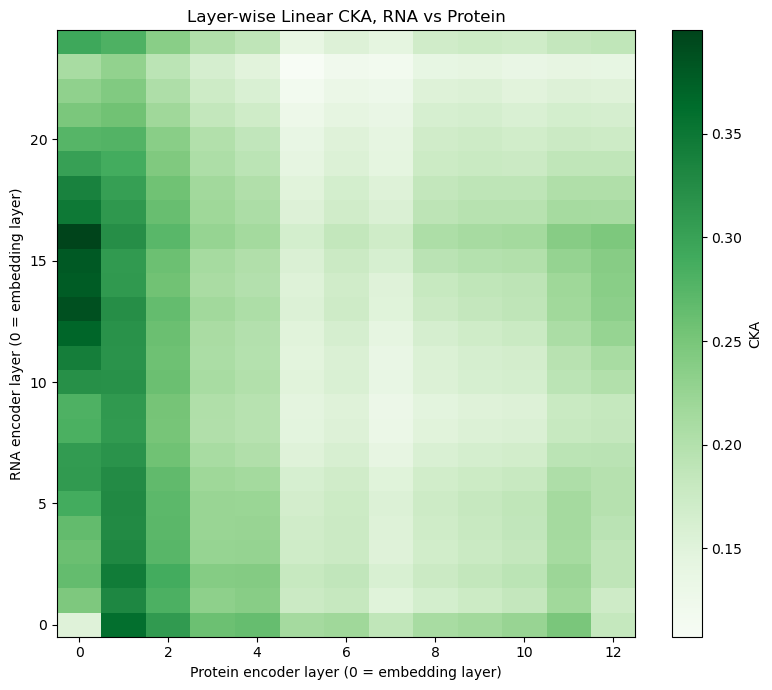

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cka_matrix, cmap="Greens", aspect="auto", origin="lower")
ax.set_xlabel("Protein encoder layer (0 = embedding layer)")
ax.set_ylabel("RNA encoder layer (0 = embedding layer)")
ax.set_title("Layer-wise Linear CKA, RNA vs Protein")
plt.colorbar(im, ax=ax, label="CKA")
plt.tight_layout()
plt.show()

**Saved results.** The full search reports a maximum CKA of **0.400** at RNA state 16 and protein state 0. After excluding protein state 0, the maximum is **0.359** at RNA state 0 and protein state 1. Both reported maxima therefore involve an initial embedding output on one side. These are descriptive maxima selected from this matrix, not independently validated layer choices.

The final-state pair is **0.187** in this subsample analysis, compared with **0.128** for the earlier 981-row comparison. The inputs come from different sampling paths, and this cell reads `hidden_states[-1]` whereas the earlier helper reads `last_hidden_state`. Those output fields are not guaranteed to be identical for every model implementation. The present comparison does not isolate the cause of the score difference or estimate its uncertainty. See the [Transformers output-field caveat](https://huggingface.co/docs/transformers/main_classes/output).

The location of the maxima, together with the earlier composition probes, motivates a hypothesis that sequence composition contributes to the observed similarity. Mean pooling averages token vectors, so token frequencies can influence the pooled representation, particularly before transformer blocks add context. That is a reason to test composition as an explanation, not a measurement of how much similarity it explains or evidence of shared biological function. The following neighborhood and CCA analyses examine other forms of correspondence; none of these geometry results alone determines whether combining representations improves stability prediction.


#### Neighborhood overlap across representations


CKA summarizes similarity across representation matrices. Neighborhood overlap asks a more local question: for a particular retained row, are the examples nearest to it in RNA space also nearest to it in protein space? Neighbor identities refer to the same paired rows in both matrices, not to equal feature coordinates.

**1. Count shared neighbors for each row.**

$$
o_i = \frac{\left|N_X(i)\cap N_Y(i)\right|}{k}.
$$

In this notation:

- $X$ is `rna_embeds`, with shape `(n, p)`, and $Y$ is `prot_embeds`, with shape `(n, q)`. The matrices contain $n$ paired examples; $p$ and $q$ are their respective feature counts.
- $i$ identifies the query example, from 1 through $n$ in the equation. Python indexes those same rows from 0 through `n - 1`.
- $k$ is the number of neighbor indices retained per query in each space; the call below uses $k=10$. Requesting one extra neighbor requires $1\le k\le n-1$.
- $N_X(i)$ and $N_Y(i)$ are the sets of retained neighbor-row indices for query $i$ in RNA and protein space, respectively. Parentheses specify which query's set is being selected.
- $\cap$ means set intersection: keep only indices appearing in both sets.
- The vertical bars $|\cdot|$ count the indices in that intersection. They denote a set's size, not a vector norm.
- $o_i$ is the shared-neighbor fraction for row $i$, a scalar between 0 and 1. Dividing the shared count by $k$ puts queries on the same scale.

For example, if 3 of a row's 10 retained neighbors are shared, its fraction is $o_i=3/10=0.3$.

**2. Average the row fractions.**

$$
\operatorname{overlap@}k
=\frac{1}{n}\sum_{i=1}^{n}o_i.
$$

In this notation:

- $\operatorname{overlap@}k$ names the final mean overlap at the chosen neighbor count $k$. The `@` reads “at”; it is part of the metric's name.
- $\sum_{i=1}^{n}$ adds the scalar fractions $o_i$ over all $n$ query rows; dividing by $n$ takes their mean.

**Connection to the code.** The notebook's `mutual_knn_alignment` helper calculates each $o_i$ in its `overlaps` list and returns their mean with `np.mean(overlaps)`. Despite the helper's name, this is overlap between two neighbor sets, not a check that neighbor relationships are reciprocal.

The helper uses the default Euclidean distance of [`NearestNeighbors`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html). It requests $k+1$ neighbors and removes the first returned index with `[i, 1:]`, intending to exclude the query itself. With duplicate vectors or distance ties, that first index need not be the query's own index; explicit self-exclusion remains an evaluation issue. The sets in the equations describe what the code retains under this rule, rather than guaranteeing that all retained neighbors are other rows.

**The chance reference uses an idealized selection rule.** For two independent, uniformly selected sets of $k$ nonself neighbors among $n-1$ candidates, the expected overlap fraction is $k/(n-1)$. Here, $n-1$ excludes the query row. Each of the $k$ neighbors in one set has probability $k/(n-1)$ of appearing in the other. The printed $k/n$ is a nearby approximation, using all $n$ rows in the denominator. This reference is not a simulated random-embedding result or a significance test, and disagreement with CKA would not by itself invalidate either metric.


In [ ]:
def mutual_knn_alignment(X, Y, k=10):
    """Average neighbor-set overlap after discarding each first returned index."""
    n = X.shape[0]
    neighbors_x = (
        NearestNeighbors(n_neighbors=k + 1)
        .fit(X)
        .kneighbors(X, return_distance=False)
    )
    neighbors_y = (
        NearestNeighbors(n_neighbors=k + 1)
        .fit(Y)
        .kneighbors(Y, return_distance=False)
    )
    # The first-neighbor removal assumes that index is the query itself.
    overlaps = [
        len(set(neighbors_x[i, 1:]) & set(neighbors_y[i, 1:])) / k
        for i in range(n)
    ]
    return np.mean(overlaps)


score = mutual_knn_alignment(rna_embeds, prot_embeds, k=10)
print(f"Mutual k-NN alignment (k=10), RNA vs protein: {score:.3f}")
print(f"Chance level for {len(rna_embeds)} points: roughly {10/len(rna_embeds):.4f}")


Mutual k-NN alignment (k=10), RNA vs protein: 0.070
Chance level for 981 points: roughly 0.0102


#### Canonical correlation and cross-modal retrieval

The previous metrics compare the representations without learning a cross-modal projection. Canonical correlation analysis (CCA) instead fits linear combinations of features that vary together across paired RNA and protein examples. It can reveal correspondence in selected directions even when a whole-matrix comparison is modest.

**1. Fit the transformations on training rows.**

The code splits the paired row indices into 70% training and 30% test rows using `SEED`. The same indices select both modalities. Write $n_{\mathrm{train}}$ for the number of training pairs and $n_{\mathrm{test}}$ for the number of test pairs; $p$ and $q$ are the respective RNA and protein embedding widths.

Each modality receives a separate principal component analysis (PCA), fitted only on its training matrix, retaining 50 components. PCA supplies a smaller feature space using directions of large training-set variation. The implementation centers features without standardizing their variances before PCA. See [the PCA definition and implementation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

The code then fits `CCA(n_components=10)` on the two reduced training matrices, using CCA's default input scaling. It applies the fitted PCA and CCA transformations to test rows without refitting them. The shape changes make the roles of 50 and 10 explicit:

| Code operation | Input shape → output shape | Meaning |
|---|---|---|
| `pca_rna.transform(rna_embeds[test_idx])` | `(n_test, p)` → `(n_test, 50)` | Express test RNA rows using the 50 PCA directions learned from RNA training rows. |
| `pca_prot.transform(prot_embeds[test_idx])` | `(n_test, q)` → `(n_test, 50)` | Express the paired protein rows using their separately fitted PCA. |
| `cca.transform(rna_test_r, prot_test_r)` | Two `(n_test, 50)` matrices → two `(n_test, 10)` matrices | Produce RNA and protein canonical coordinates using the fitted CCA transformations. |

In the table, `n_test` means $n_{\mathrm{test}}$. The training PCA outputs similarly have shape `(n_train, 50)` before CCA is fitted.

**2. Understand one canonical pair.**

CCA starts by seeking one weighted combination of the reduced RNA features and one of the reduced protein features. For the first pair, write the two projected vectors as

$$
\mathbf u = \widetilde X_{\mathrm{train}}\mathbf a.
$$

The corresponding protein projection is:

$$
\mathbf v = \widetilde Y_{\mathrm{train}}\mathbf b.
$$

In this notation:

- $n_{\mathrm{train}}$ and $n_{\mathrm{test}}$ count the paired training and test examples. The subscripts identify their partitions.
- $p$ and $q$ are the respective original RNA and protein embedding widths, before PCA reduces each to 50 features.
- $\widetilde X_{\mathrm{train}}$ and $\widetilde Y_{\mathrm{train}}$ are the RNA and protein training matrices after PCA reduction and CCA's internal centering and scaling. Each has shape `(n_train, 50)`.
- The tilde, read as “X tilde” or “Y tilde,” marks these processed matrices. It does not mean an approximation here. The subscript “train” identifies their training rows.
- $\mathbf a$ and $\mathbf b$ are coefficient vectors with 50 entries each: one coefficient for each PCA feature in the respective modality. Bold lowercase symbols here represent vectors.
- Matrix–vector multiplication, such as $\widetilde X_{\mathrm{train}}\mathbf a$, multiplies each row's 50 feature values by the corresponding 50 coefficients and adds them. It produces one number per training row.
- $\mathbf u$ and $\mathbf v$ are therefore vectors of length $n_{\mathrm{train}}$, containing one canonical coordinate per training example in each modality. They are not the 50 coefficients themselves.

For a small illustration with only two features, a processed row `[2, 3]` and coefficients `[0.5, -1]` give the single coordinate $2(0.5)+3(-1)=-2$. The actual calculation combines 50 features per row. These illustrative values are not fitted notebook results.

The first-pair objective is

$$
(\mathbf a^\star,\mathbf b^\star)
=
\underset{\mathbf a,\mathbf b}{\operatorname{arg\,max}}\;
\operatorname{corr}\!\left(\widetilde X_{\mathrm{train}}\mathbf a,\,
                          \widetilde Y_{\mathrm{train}}\mathbf b\right).
$$

In this notation:

- $\operatorname{corr}$ means Pearson correlation across paired training rows: it measures how the two projected vectors vary together. Both projected vectors must have nonzero variance for this correlation to be defined.
- $\operatorname{arg\,max}$ means “find coefficient vectors that make the correlation as large as possible.” It returns the coefficient choices, rather than the maximum correlation value.
- The $\mathbf a,\mathbf b$ below the operator identify the quantities being chosen; the processed training matrices remain fixed.
- The stars in $\mathbf a^\star$ and $\mathbf b^\star$ label optimizing coefficient vectors. They do not mean multiplication or another power. Each selected vector still has 50 entries.

This equation describes the first-pair mathematical objective behind the library method. The notebook delegates fitting to `CCA.fit`; it does not implement this optimization itself. The library learns subsequent pairs after removing previously captured variation and constructs the transformations used by `CCA.transform`. Requesting 10 components therefore yields 10 coordinates per example in each modality, with each coordinate formed from the 50 input features. A canonical coordinate is a learned numerical combination, not an identified biological mechanism. See [CCA](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.CCA.html) and the [cross-decomposition guide](https://scikit-learn.org/stable/modules/cross_decomposition.html#canonical-correlation-analysis).

The notebook measures test correlations by applying `np.corrcoef` to corresponding columns of `rna_test_c` and `prot_test_c`, pairing the same test rows. Test correlations need not decrease with component index: the component order was learned from the training rows.

**3. Retrieve the paired protein row for each test RNA row.**

Each test RNA vector queries the test protein vectors by Euclidean distance in the resulting 10-dimensional coordinates. Its designated correct match is the protein row with the same test-set index. The code measures

$$
\operatorname{Recall@}k
=
\frac{1}{n_{\mathrm{test}}}
\sum_{i=1}^{n_{\mathrm{test}}}
\mathbf{1}\!\left\{i\in R_k(i)\right\}.
$$

In this notation:

- $k$ is the number of retrieved protein candidates considered per RNA query. The notebook reports 1, 5 and 10; the formula assumes $1\le k\le n_{\mathrm{test}}$.
- $i$ identifies a paired test row, from 1 through $n_{\mathrm{test}}$ in the equation. Python uses indices 0 through `n_test - 1`. These are positions within the test arrays, not the original dataset's row numbers.
- $R_k(i)$ is the set of the first $k$ protein indices returned for RNA query $i$; the subscript $k$ records the chosen candidate count.
- $\in$ means “is a member of.” Thus, $i\in R_k(i)$ asks whether the designated protein match appears among those candidates.
- $\mathbf{1}\{\cdot\}$ is an indicator: it returns the scalar 1 if the statement in braces is true and 0 otherwise. This bold 1 is not an embedding vector.
- $\sum_{i=1}^{n_{\mathrm{test}}}$ adds the successful-match indicators, and division by $n_{\mathrm{test}}$ gives the fraction of successful queries.
- $\operatorname{Recall@}k$ names that fraction, read as “recall at k.” There is one designated correct match per query here.

For example, if query 4 returns protein indices `[8, 4, 2]`, it fails at $k=1$ but succeeds at $k=3$. In the code, `i in neighbor_idx[i, :k]` performs the membership check; `correct / n_test` gives the reported fraction. Tied distances at the cutoff inherit the library's returned ordering.

**The chance reference is a ranking calculation.** A uniformly random ranking has expected success $k/n_{\mathrm{test}}$ for $k\le n_{\mathrm{test}}$: the one designated match has $k$ successful positions among $n_{\mathrm{test}}$ possible positions. For the 295 test rows in the saved run, top-1 chance is $1/295\approx0.0034$, or about **0.34%**. This is a ranking reference, not a $p$-value.

Training the transformations only on training rows avoids fitting those transformations to test rows. This is still a row-level split: it does not ensure that duplicate or biologically related sequences stay in the same partition. Neither CCA fitting nor retrieval uses the stability labels.


In [ ]:
# Keep the RNA and protein rows paired through the same split.
train_idx, test_idx = train_test_split(
    np.arange(len(rna_embeds)), test_size=0.3, random_state=SEED
)

pca_rna = PCA(n_components=50, random_state=SEED).fit(rna_embeds[train_idx])
pca_prot = PCA(n_components=50, random_state=SEED).fit(prot_embeds[train_idx])

rna_train_r, prot_train_r = (
    pca_rna.transform(rna_embeds[train_idx]),
    pca_prot.transform(prot_embeds[train_idx]),
)
rna_test_r, prot_test_r = (
    pca_rna.transform(rna_embeds[test_idx]),
    pca_prot.transform(prot_embeds[test_idx]),
)

cca = CCA(n_components=10).fit(rna_train_r, prot_train_r)
rna_test_c, prot_test_c = cca.transform(rna_test_r, prot_test_r)

print("Canonical correlations on held-out test data:")
for i in range(10):
    corr = np.corrcoef(rna_test_c[:, i], prot_test_c[:, i])[0, 1]
    print(f"  Component {i + 1}: {corr:.3f}")

# Query protein candidates using the RNA coordinates; index i is the paired row.
n_test = len(test_idx)
nn = NearestNeighbors(n_neighbors=min(10, n_test)).fit(prot_test_c)
_, neighbor_idx = nn.kneighbors(rna_test_c)

print("\nCross-modal retrieval on held-out test data:")
for k in (1, 5, 10):
    correct = sum(i in neighbor_idx[i, :k] for i in range(n_test))
    print(f"  Recall@{k}: {correct / n_test:.3f} (chance level: {k / n_test:.4f})")


Canonical correlations on held-out test data:
  Component 1: 0.955
  Component 2: 0.914
  Component 3: 0.846
  Component 4: 0.872
  Component 5: 0.786
  Component 6: 0.772
  Component 7: 0.588
  Component 8: 0.670
  Component 9: 0.537
  Component 10: 0.584

Cross-modal retrieval on held-out test data:
  Recall@1: 0.366 (chance level: 0.0034)
  Recall@5: 0.614 (chance level: 0.0169)
  Recall@10: 0.759 (chance level: 0.0339)


**Saved observations.** The neighborhood-overlap score is **0.070** at $k=10$, above the printed approximate reference of **0.0102**. It measures local neighbor agreement under the current self-removal rule; it does not establish a calibrated significance level or validate the CKA result.

The largest reported test canonical correlation is **0.955**, for component 1. Retrieval gives **Recall@1 = 0.366**, **Recall@5 = 0.614**, and **Recall@10 = 0.759**. Thus, the designated protein row ranks first for 36.6% of the test RNA queries under this fitted projection, compared with the uniform-ranking reference of about 0.34%.

These results show correspondence accessible to the fitted PCA–CCA pipeline on this row split. They can coexist with modest CKA because fitting projections changes which directions are being compared. The test-row evaluation does not rule out overfitting, related-sequence leakage, or sensitivity to the chosen split.

The analyses do not identify the biological cause of the correspondence. Composition is one hypothesis suggested by earlier probes, but no composition-controlled comparison here establishes it. Retrieval also addresses a different target from stability prediction: it neither explains the concatenation result nor demonstrates that a learned fusion method will improve stability prediction. That connection requires matched predictive experiments.


#### Two-dimensional UMAP views


UMAP provides a visual summary of neighborhoods in each final-layer embedding matrix. Each plotted point represents one retained row, and the two coordinates are fitted visualization coordinates. The code fits the RNA and protein projections separately; their axes do not form a shared coordinate system, even though their rows correspond.

Both calls use `random_state=SEED`. Fixing the random state supports repeatability of this stochastic projection, while the neighborhood and spacing settings still affect its appearance. See the [UMAP parameter guide](https://umap-learn.readthedocs.io/en/latest/parameters.html) and [reproducibility documentation](https://umap-learn.readthedocs.io/en/latest/reproducibility.html).

Use these plots to suggest examples or groups for further inspection. A two-dimensional layout does not preserve every relationship in the original space, and it does not replace the quantitative comparisons above.


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


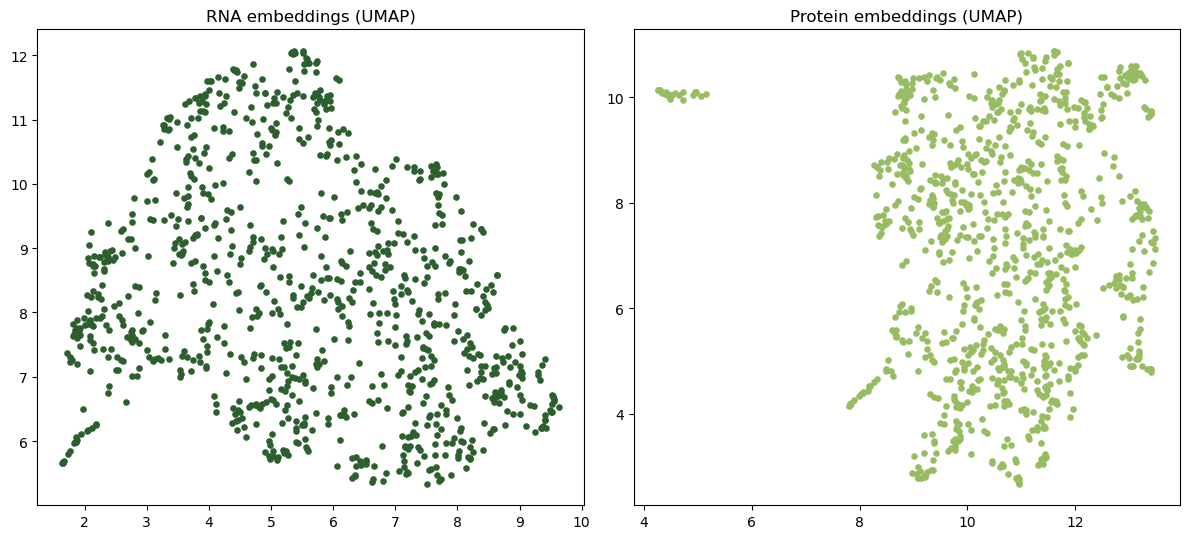

In [ ]:
# Fit each visualization independently; the two coordinate systems are separate.
coords_rna = umap.UMAP(random_state=SEED).fit_transform(rna_embeds)
coords_prot = umap.UMAP(random_state=SEED).fit_transform(prot_embeds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].scatter(coords_rna[:, 0], coords_rna[:, 1], s=14, color="#2C5F2D")
axes[0].set_title("RNA embeddings (UMAP)")
axes[1].scatter(coords_prot[:, 0], coords_prot[:, 1], s=14, color="#97BC62")
axes[1].set_title("Protein embeddings (UMAP)")
plt.tight_layout()
plt.show()


**Saved plots.** The protein projection contains a small group separated to the left of its main cloud. This provides a concrete set of points to trace back to the source rows for further inspection.

Similar-looking groups in these separate layouts do not establish that they contain the same rows. The plots do not label individual examples or species, so they cannot identify a shared outlier group or a species-specific explanation. Such claims would require tracing the plotted rows back to verified metadata and checking the original representations. The present figures are exploratory views, not evidence of a particular biological grouping.


---

### Pipeline control: synonymous recoding


The `mRFP_Expression` control asks whether the pipeline behaves as expected when different nucleotide sequences encode the same protein. A synonymous recoding changes codons while retaining the amino-acid sequence. Identical translated strings should therefore give the protein encoder the same input, while the nucleotide encoder can receive different inputs.

The code loads the control CSV, removes rows with missing sequences, samples `N_ROWS` rows with `SEED`, and applies the existing `embed_dataset` helper. It then counts distinct translated protein strings among the retained rows. The two embedding matrices, `control_rna` and `control_prot`, are examined separately to measure how spread out their rows are.

**1. Find the centroid: the average embedding.**

Treat each embedding as a point whose coordinates are its numerical features. The centroid is the average of those points, calculated one feature at a time:

$$
\bar{\mathbf z}
= \frac{1}{n}\sum_{i=1}^{n}\mathbf z_i.
$$

In this notation:

- $Z$ denotes whichever embedding matrix is being examined: `control_rna` or `control_prot`. Its shape is `(n, d)`.
- $n$ is the number of retained control rows in that matrix.
- $d$ is the number of embedding features in each row; the two encoders have different feature counts.
- $i$ identifies an example row, from 1 through $n$ in the equation. Python indexes those same rows from 0 through `n - 1`.
- $\mathbf z_i$, read as "bold z sub i," is the embedding vector in row $i$. Bold symbols here represent vectors with $d$ coordinates.
- $\bar{\mathbf z}$, read as "z bar," is the centroid vector. The bar denotes the average across rows.
- $\sum_{i=1}^{n}$ means to add the row vectors coordinate by coordinate. Dividing by $n$ takes the average for each feature.

**2. Measure each embedding's distance from the centroid.**

Subtract the centroid from a row, then measure the length of that difference vector:

$$
r_i = \left\|\mathbf z_i-\bar{\mathbf z}\right\|_2.
$$

In this notation:

- $r_i$ is a single nonnegative number: the distance of row $i$ from the centroid.
- $\mathbf z_i-\bar{\mathbf z}$ subtracts the centroid's value from each corresponding feature in that row.
- $\|\cdot\|_2$ denotes Euclidean length: square each coordinate of the vector inside the bars, add the squares, and take the square root. The subscript 2 identifies this choice of norm; it does not mean the embedding has two features.

An embedding at the centroid has distance zero. A larger distance means that embedding lies farther from the average within this representation space.

**3. Average the distances to obtain one spread value.**

$$
\operatorname{spread}(Z)
= \frac{1}{n}\sum_{i=1}^{n}r_i.
$$

In this notation:

- $\operatorname{spread}(Z)$ names the mean distance for matrix $Z$. It is one scalar, not another embedding vector or a variance.
- $n$, $i$ and the summation have the same meanings as above; this time the quantities being averaged are the scalar distances $r_i$.

**Connection to the code.**

These equations describe the NumPy calculation inside the `protein_spread` and `rna_spread` assignments in the next cell. There is no fitted model or separate function named `spread` here. The mathematical names for the centroid and individual distances explain intermediate results that the code calculates within each assignment.

The protein assignment performs the following operations in order. Its RNA counterpart substitutes `control_rna` for `control_prot`.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `control_prot.mean(axis=0)` | `(n, d)` → `(d,)` | Average down the example rows to obtain the centroid $\bar{\mathbf z}$. |
| `control_prot - control_prot.mean(axis=0)` | `(n, d)` → `(n, d)` | Subtract that same centroid from every row. |
| `np.linalg.norm(..., axis=1)` | `(n, d)` → `(n,)` | Combine the feature differences within each row into its distance $r_i$. |
| The final `.mean()` | `(n,)` → scalar | Average the distances to obtain $\operatorname{spread}(Z)$. |

The `...` in the table stands for the centered matrix from the preceding row. NumPy applies the centroid subtraction to every row automatically. With `axis=1` and the default norm setting, `np.linalg.norm` calculates Euclidean length across each row's features; see [NumPy's norm definition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html). The code performs these spread calculations only when more than one control row is retained.

**Small worked example.**

Suppose there are two embeddings, $(1,2)$ and $(5,2)$, so $n=2$ and $d=2$.

1. Their centroid is $(3,2)$: each coordinate is the average of that feature's two values.
2. Subtracting the centroid gives $(-2,0)$ and $(2,0)$. Each difference vector has Euclidean length 2.
3. The spread is therefore $(2+2)/2=2$.

These are illustrative numbers, not outputs from either encoder.

**What this control can establish.**

Identical vectors have zero spread in exact arithmetic. Near-zero protein spread together with one distinct translated protein is consistent with the expected behavior for synonymous recodings; nonzero nucleotide spread shows variation among the nucleotide representations. Compare each matrix with its own centroid. Because the two spaces have different dimensions and scales, their raw spread values do not form a normalized comparison of information content. This control checks this particular translation/embedding relationship, not every assumption or analysis elsewhere in the notebook.


In [ ]:
print("Every variant here is a synonymous recoding of one gene, so they should")
print("all translate to the identical protein. This checks that the pipeline")
print("actually behaves that way before trusting results on the main dataset.\n")

control_df = (
    pd.read_csv(CONTROL_CSV_PATH)
    .dropna(subset=[SEQ_COLUMN])
    .sample(n=N_ROWS, random_state=SEED)
)
control_rna, control_prot, control_proteins, _ = embed_dataset(
    control_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

unique_proteins = set(control_proteins)
print(
    f"Unique translated protein sequences across {len(control_proteins)} variants: {len(unique_proteins)}"
)
if len(unique_proteins) == 1:
    print("  As expected: every variant encodes the same protein.")
else:
    print(
        "  Unexpected: variants encode different proteins. Check the frame and start codon on this file."
    )

if len(control_prot) > 1:
    # Measure each matrix relative to its own centroid and feature scale.
    protein_spread = np.linalg.norm(
        control_prot - control_prot.mean(axis=0), axis=1
    ).mean()
    rna_spread = np.linalg.norm(
        control_rna - control_rna.mean(axis=0), axis=1
    ).mean()
    print(
        f"  Average distance to centroid, protein embeddings: {protein_spread:.5f} (should be near zero)"
    )
    print(
        f"  Average distance to centroid, RNA embeddings:     {rna_spread:.5f} (should be clearly nonzero)"
    )


Every variant here is a synonymous recoding of one gene, so they should
all translate to the identical protein. This checks that the pipeline
actually behaves that way before trusting results on the main dataset.

Unique translated protein sequences across 1000 variants: 1
  As expected: every variant encodes the same protein.
  Average distance to centroid, protein embeddings: 0.00003 (should be near zero)
  Average distance to centroid, RNA embeddings:     4.72361 (should be clearly nonzero)


**Saved control result.** All 1,000 retained `mRFP_Expression` variants translated to one identical protein sequence. Their protein embeddings were nearly identical, with mean distance to centroid **0.00003**, while the RNA embeddings varied, with mean distance **4.72361**. This supports the expected behavior for synonymous recodings: nucleotide inputs vary while the translated protein input stays fixed.

The two embedding spaces have different dimensions and scales, so their raw spread values are not a normalized comparison of information content. This control checks a specific translation/embedding behavior; it does not validate every reading-frame assumption, stability label, or representation-analysis result on the main dataset.


---

### Track C: Attention and exploratory diagnostics

Track A asks which targets a simple model can recover from the frozen embeddings. Track B compares the geometry of final-layer and intermediate representations. Track C examines a selected summary of nucleotide-model attention at candidate RNA motif positions, followed by exploratory alignment–error and representation-distance diagnostics.

The attention analysis follows a sequence of transformations: extract self-attention weights, summarize them by token, map those summaries to nucleotide positions, scan the input for candidate patterns, and compare scores inside and outside the matched spans. The resulting plots and statistics describe the selected model behavior. A pattern match is not a validated regulatory site, and attention is not a direct assay of regulatory function.

These diagnostics can motivate specific follow-up experiments. An alignment–error correlation does not measure the effect of adding an alignment loss, and the observations do not select a fusion architecture by themselves.


#### Extracting self-attention from the frozen nucleotide encoder


The previous analyses used extracted representations, including those from intermediate layers. Here, `get_attention_maps` requests `output_attentions=True` for one nucleotide sequence. These are **self-attention** weights: query and key positions belong to the same sequence, rather than to separate RNA and protein inputs.

Each layer returns an array with shape `(1, H, T, T)`. The leading 1 is the one-sequence batch size. Removing that axis leaves `(H, T, T)`: heads, query positions and key positions.

In this notation:

- $H$ is the number of attention heads in this layer. A head is one of the parallel attention computations.
- $T$ is the number of processed input tokens, including special tokens.
- $h$ identifies a head, while $q$ and $k$ identify a query and a key token position. The equations below count heads from 1 through $H$ and positions from 1 through $T$; NumPy indexes their axes from zero.
- $A^{(h)}_{qk}$ is one scalar weight assigned by query position $q$ to key position $k$ in head $h$. The parenthesized superscript selects a head; it is not a power. The two subscripts select a row and column of that head's attention matrix.

**Connection to the code.** Inside `get_attention_maps`, `outputs.attentions` holds the per-layer arrays. Each `layer_att.squeeze(0).cpu().numpy()` removes the batch axis and returns that layer's weights as a NumPy array. The list `attentions` preserves layer order, and `tokens` gives the token strings for the same model call. These weights participate in a weighted combination of value vectors; they are not a complete decomposition of the final representation or a direct measure of biological importance. See the attention construction in [Vaswani et al. (2017), Section 3.2](https://arxiv.org/html/1706.03762v7#S3.SS2) and the [ESM output definitions](https://huggingface.co/docs/transformers/en/model_doc/esm#transformers.EsmModel).

The code loads a separate instance, `rna_model_attn`, with `attn_implementation="eager"` to obtain the explicit attention weights used below. This is a choice for attention inspection in this pipeline; support for returning weights depends on the model and attention backend. The [Transformers attention-backend documentation](https://huggingface.co/docs/transformers/en/attention_interface) explains how that argument selects the implementation. The original `rna_model` and previously computed representations remain separate objects.

The new instance is placed in evaluation mode, and inference runs inside `torch.no_grad()`. No parameter update is performed. Tokenization uses `truncation=True` without an explicit `max_length` here, whereas embedding extraction passes a configured limit. The returned token list describes this model call's processed input and may cover less than the full sequence; its coverage must be checked rather than assumed to match earlier extraction.


In [ ]:
def get_attention_maps(model, tokenizer, sequence, device="cpu"):
    """Return per-layer self-attention arrays and tokens for one input sequence.

    Arrays have shape (heads, query_tokens, key_tokens). Tokenization may
    truncate the input; the caller supplies a model in evaluation mode.
    """
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    # Remove the singleton batch axis and move each layer's weights to the CPU.
    attentions = [
        layer_att.squeeze(0).cpu().numpy() for layer_att in outputs.attentions
    ]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return attentions, tokens


In [ ]:
rna_model_attn = AutoModel.from_pretrained(
    RNA_MODEL_NAME, trust_remote_code=True, attn_implementation="eager"
).to(DEVICE).eval()

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The saved loading warning above names newly initialized `esm.pooler.dense.bias` and `esm.pooler.dense.weight`. These belong to the pooler; the warning does not describe unexpected language-model-head weights. This analysis reads `outputs.attentions` and does not use a pooled output from that module. The warning should therefore be interpreted in relation to the outputs consumed here, rather than treated as a general confirmation that every model component has pretrained weights.


#### Summarizing attention and mapping tokens to nucleotides


`aggregate_attention` turns one layer's `(H, T, T)` array into one score per token. With `mode="incoming"`, the score summarizes how much attention a key position receives from all query positions after averaging heads. `layer=-1` selects the final transformer layer; this is the current analysis choice, not evidence that it is the most informative layer.

**1. Average the heads.**

$$
\bar A_{qk}=\frac{1}{H}\sum_{h=1}^{H}A^{(h)}_{qk}.
$$

In this notation:

- $A^{(h)}_{qk}$ is the selected layer's weight from query token $q$ to key token $k$ in head $h$, as defined above.
- $H$ is the number of heads; $h$ runs from 1 through $H$ in the equation.
- $q$ and $k$ each run from 1 through $T$, where $T$ is the processed token count, including special tokens.
- $\bar A$ is a `(T, T)` matrix. The bar means an average across heads at each fixed query/key pair; it does not average token positions.
- $\sum$ adds the $H$ weights for that pair, and division by $H$ gives their mean.

**2. Sum incoming weight for each key token.**

$$
s_k=\sum_{q=1}^{T}\bar A_{qk}.
$$

In this notation:

- $s_k$ is the incoming score for key token $k$ before rescaling.
- The sum varies the query index $q$ while holding $k$ fixed: it adds one column of $\bar A$.
- The full score vector has $T$ entries. It is a summary of attention weights, not an embedding vector of biological features.

**3. Rescale scores within this sequence.**

$$
\widetilde s_k=
\frac{s_k-\min_j s_j}{\max_j s_j-\min_j s_j+\varepsilon}.
$$

In this notation:

- $\widetilde s_k$ is the returned score; the tilde marks the rescaled quantity.
- $j$ ranges over all $T$ token positions. $\min_j s_j$ and $\max_j s_j$ are the smallest and largest incoming scores in this sequence.
- $\varepsilon=10^{-8}$ is the small constant `1e-8` in the code. It prevents division by zero when every score is equal; in that case all returned scores are zero.

This subtraction and division retain the ordering of unequal scores while changing their scale. For nonconstant scores, the maximum is below 1 in exact arithmetic because of the added constant; it approaches 1 when the score range is large relative to that constant. Scores are rescaled separately for each sequence, so equal displayed scores from different sequences are not calibrated to the same amount of incoming attention. Special-token positions participate in all three steps.

**Connection to the code.** These are direct array operations inside `aggregate_attention`; none of the three equations fits a model.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `attentions[layer].mean(axis=0)` | `(H, T, T)` → `(T, T)` | Compute the head average $\bar A$. |
| `layer_att.sum(axis=0)` | `(T, T)` → `(T,)` | Sum query rows to obtain the incoming scores $s_k$. |
| `(score - score.min()) / (score.max() - score.min() + 1e-8)` | `(T,)` → `(T,)` | Return the rescaled scores $\widetilde s_k$. |

The axes have different meanings at each step: after averaging removes the head axis, axis 0 refers to query positions. Any `mode` value other than `"incoming"` selects `sum(axis=1)` instead, producing outgoing row sums; the calls in this notebook use `"incoming"`.

For an illustrative head-averaged matrix with rows `(0.8, 0.2)` and `(0.4, 0.6)`, the incoming scores are `(1.2, 0.8)`. Rescaling gives approximately `(1, 0)`. This example describes the calculation, not an observed model output or a claim that the second token has no biological role.

**Map token scores to nucleotide positions.**

The motif scan uses nucleotide positions rather than token positions. The [Nucleotide Transformer model card](https://huggingface.co/InstaDeepAI/nucleotide-transformer-500m-human-ref#preprocessing) describes six-nucleotide tokens where possible and individual-nucleotide tokens otherwise. `expand_token_attention_to_nucleotides`:

1. Pairs each token string with its returned score.
2. Skips strings beginning with `<` or `[`, the helper's rule for special tokens.
3. Repeats each remaining score once per character in that token and appends the copies in token order.

For example, if `ACGTAC` is the first retained token and has score 0.25, expanded positions 0 through 5 all receive 0.25. This copies one token score onto six positions; it does not estimate six independent nucleotide scores. No further normalization occurs after removing special tokens.

The mapping assumes the retained token strings spell the covered nucleotides in order. It is not a general mapping for arbitrary tokenizers or unknown-token behavior, and it cannot restore positions removed by truncation. The example execution prints sequence and expanded-array lengths as a diagnostic; it does not enforce equality.


In [ ]:
def aggregate_attention(attentions, layer=-1, mode="incoming"):
    """Summarize one layer and min-max rescale its token-position scores.

    Incoming scores sum over queries after averaging heads. Other mode values
    use row sums. Special-token positions remain included at this step.
    """
    layer_att = attentions[layer].mean(axis=0)  # (query_tokens, key_tokens)
    score = layer_att.sum(axis=0) if mode == "incoming" else layer_att.sum(axis=1)
    score = (score - score.min()) / (score.max() - score.min() + 1e-8)
    return score


In [ ]:
def expand_token_attention_to_nucleotides(attn_score, tokens):
    """Repeat scores by token-string length after excluding special tokens.

    Assumes retained token strings spell the covered nucleotides in order.
    The expansion cannot restore sequence positions removed by truncation.
    """
    expanded = []
    for score, tok in zip(attn_score, tokens):
        if tok.startswith("<") or tok.startswith("["):
            continue
        expanded.extend([score] * len(tok))
    return np.array(expanded)


#### Scanning candidate RNA stability-associated patterns


The scan creates **candidate sequence-pattern annotations** for the attention comparison. It searches the input sequence for three RNA-relevant patterns; it does not measure binding, modification, or a change in stability.

| Pattern | What the scan identifies | Interpretation limit |
|---|---|---|
| AUUUA | ARE-associated pentamer | A match alone does not establish an active AU-rich element or altered stability. |
| UUAUUUAUU | ARE-associated nonamer | Contains the pentamer; these are related patterns rather than independent mechanistic classes. |
| DRACH | Consensus associated with candidate m6A sites | D = A/G/U, R = A/G, H = A/C/U. The central A is a potential methylation site; a match does not establish methylation. |

The ARE patterns have experimental precedent in [Zubiaga et al. (1995)](https://pmc.ncbi.nlm.nih.gov/articles/PMC230450/). Single-nucleotide mapping shows that only a subset of DRACH candidates are methylated; see [Linder et al. (2015)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4487409/). Motif occurrence, molecular modification or binding, and a functional effect on stability are distinct claims.

`iupac_to_regex` converts each IUPAC symbol to its permitted letters in the DNA alphabet. For example, DRACH becomes `[AGT][AG]AC[ACT]`, with U represented as T to match the converted sequence. `find_iupac_matches` uses a regex lookahead to include overlapping occurrences. It returns zero-based, end-exclusive intervals: `start` is covered and `end` is the first position after the match. `scan_sequence_for_motifs` adds the pattern name and a fixed score of `1.0`, which indicates a consensus match rather than a confidence or binding score. Subsequent masks cover the entire matched span, including all five DRACH positions, rather than only its central A.

These annotations depend only on sequence and require no external database call. The [CodonBERT source repository](https://github.com/Sanofi-Public/CodonBERT) links the stability task to [iCodon](https://www.nature.com/articles/s41598-022-15526-7), which studies coding-sequence codon composition. The exact region and label mapping for the local CSV still need verification; its columns do not establish UTR coverage. Presence or absence of these patterns therefore needs interpretation in the context of the sequence region.


In [ ]:
def iupac_to_regex(pattern):
    """Convert an IUPAC consensus pattern to a regex on the DNA alphabet."""
    IUPAC = {
        "A": "A", "C": "C", "G": "G", "T": "T", "U": "T",
        "R": "[AG]", "Y": "[CT]", "S": "[GC]", "W": "[AT]",
        "K": "[GT]", "M": "[AC]", "B": "[CGT]", "D": "[AGT]",
        "H": "[ACT]", "V": "[ACG]", "N": "[ACGT]",
    }
    return "".join(IUPAC[b] for b in pattern.upper())


def find_iupac_matches(sequence, iupac_pattern):
    """Return all matching zero-based, end-exclusive spans, including overlaps."""
    seq = sequence.upper().replace("U", "T")
    regex = iupac_to_regex(iupac_pattern)
    length = len(iupac_pattern)
    return [
        (m.start(), m.start() + length)
        for m in re.finditer(f"(?={regex})", seq)
    ]


# Candidate sequence patterns; a match is not a validated regulatory site.
STABILITY_MOTIFS = {
    "ARE_pentamer": "AUUUA",
    "ARE_nonamer": "UUAUUUAUU",
    "m6A_DRACH": "DRACH",
}


def scan_sequence_for_motifs(sequence, motifs=STABILITY_MOTIFS):
    """Return (start, end, motif_name, 1.0) for each consensus match."""
    hits = []
    for name, pattern in motifs.items():
        for start, end in find_iupac_matches(sequence, pattern):
            hits.append((start, end, name, 1.0))
    return hits


#### Comparing attention at matched and other positions


`attention_motif_overlap` compares expanded attention scores at candidate-pattern positions with scores at the other covered positions in the same sequence. It forms the union of matched spans for the pooled comparison, counting each position once, then repeats the comparison separately for each pattern name. Match ends are clipped to the attention array's length. For a per-pattern comparison, the other-position group can include positions matching a different pattern.

**1. Average the scores at matched positions.**

$$
\bar\alpha_M=\frac{1}{n_M}\sum_{p\in M}\alpha_p.
$$

In this notation:

- $L$ is the length of `attention_score`, the expanded array. Its Python positions run from 0 through `L - 1`; this need not cover the full original sequence after truncation.
- $p$ is one nucleotide-array position, rather than an example row or a p-value.
- $\alpha_p$ is the expanded attention score at position $p$. The Greek letter alpha names the value; it is not a biological measurement or a fitted coefficient.
- $M$ is the set of positions inside at least one of the spans being compared; $n_M=|M|$ is its size. The bars count distinct positions, so overlaps do not increase the count twice.
- $p\in M$ means that $p$ belongs to that set. The summation adds the scores at those positions, and division by $n_M$ takes their mean.
- $\bar\alpha_M$ is the resulting scalar mean. The bar denotes an average, and subscript $M$ identifies the group.

**2. Average the scores at the other positions.**

$$
\bar\alpha_O=\frac{1}{n_O}\sum_{p\in O}\alpha_p.
$$

In this notation:

- $O$ is the complement of $M$ within the expanded array: every covered position that is not in $M$.
- $n_O=|O|$ counts those other positions; together, $n_M+n_O=L$.
- $\bar\alpha_O$ is their scalar mean. The summation and bar have the same meanings as in step 1, applied to the other group.

Both means require a nonempty group. The nested `_test` helper returns `None` if either group is empty. That marks an unavailable comparison, not a zero effect; an unavailable pooled comparison makes the outer function return `None` too.

**3. Distinguish the mean gap from the rank test.**

The two returned means also define a descriptive difference:

$$
\Delta=\bar\alpha_M-\bar\alpha_O.
$$

In this notation:

- $\Delta$, read as “delta,” is the matched-minus-other mean gap. Positive values mean the matched group has a larger average score; negative values mean it has a smaller one.
- The two mean symbols refer to steps 1 and 2. Their difference is in the same rescaled score units, rather than a probability.

For example, matched scores `(0.2, 0.4)` have mean 0.3, while other scores `(0.1, 0.1)` have mean 0.1. Their gap is 0.2. This illustrative calculation does not determine the rank test's p-value.

The one-sided Mann–Whitney U call uses `alternative="greater"` to examine a tendency toward larger scores in the matched group. It compares ranks/distributions, rather than directly testing whether $\Delta$ is positive. The standard null is equality of the two underlying distributions, with an alternative of stochastically greater matched scores; see [SciPy's Mann–Whitney U documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

**Connection to the code.** The means are calculated now; the subtraction is performed later in the multi-sequence summary.

| Code operation | Result | Connection to the calculation |
|---|---|---|
| `_test`: select `at` and `off` from `attention_score` | Arrays with shapes `(n_M,)` and `(n_O,)` | Gather the scores in $M$ and its complement $O$. |
| `at.mean()` and `off.mean()` | Two scalars stored in the returned dictionary | Compute $\bar\alpha_M$ and $\bar\alpha_O$. |
| `mannwhitneyu(at, off, alternative="greater")` | A U statistic and a nominal p-value | SciPy performs the rank test; the dictionary retains its p-value. |
| Later, in the `mean_gap` and per-pattern `gap` assignments | One difference per usable sequence, followed by an average | Subtract the dictionary's two mean fields to compute each $\Delta$. |

There is no returned `Delta` field or separate gap function in `attention_motif_overlap`. The equation names a quantity formed from its outputs in [Running the attention–motif analysis](#Running-the-attention–motif-analysis).

Treat the p-values as **nominal**: they are the test's reported values without calibration for this positional setting. Expanding token scores repeats values; neighboring positions are dependent; patterns can overlap; and many sequence/pattern comparisons are performed without multiplicity correction. Sequence composition and tokenization can also affect both masks and scores. A small p-value or positive mean gap identifies a candidate association for follow-up, not evidence that the encoder learned functional RNA regulation. Calibrated null models and experimentally supported annotations require a separate methodological decision.


In [ ]:
def attention_motif_overlap(attention_score, motif_hits):
    """Return descriptive means and nominal one-sided rank-test p-values.

    Compare the union of covered positions with its complement, then repeat
    by pattern. Return None when the pooled comparison has an empty group.
    """
    def _test(positions):
        """Compare one position set with all other positions in the array."""
        non_positions = set(range(len(attention_score))) - positions
        if not positions or not non_positions:
            return None
        at = attention_score[list(positions)]
        off = attention_score[list(non_positions)]
        stat, pval = mannwhitneyu(at, off, alternative="greater")
        return {
            "mean_attention_at_motifs": at.mean(),
            "mean_attention_elsewhere": off.mean(),
            "n_motif_positions": len(positions),
            "p_value": pval,
        }

    all_positions = set()
    by_name = {}
    for start, end, name, score in motif_hits:
        positions = set(range(start, min(end, len(attention_score))))
        all_positions.update(positions)
        by_name.setdefault(name, set()).update(positions)

    result = _test(all_positions)
    if result is None:
        return None
    result["by_motif"] = {
        name: _test(positions) for name, positions in by_name.items()
    }
    return result


#### Plotting attention and candidate pattern spans


`plot_attention_with_motifs` combines the expanded attention array and the sequence-pattern matches in one figure. The black line shows the rescaled attention summary at each covered nucleotide index. Colored bands show matched spans, with one legend entry per pattern type. A token's repeated score can produce a flat segment across several nucleotide positions.

The plot is a qualitative companion to the numerical comparison: it makes peaks and candidate spans visible on the same coordinate axis. Visual overlap alone does not establish regulatory function or a statistically calibrated association. The plotting code draws the supplied spans as given, so interpreting the full sequence requires that attention coverage and motif coordinates agree.


In [ ]:
MOTIF_COLORS = {
    "ARE_pentamer": "#97BC62",
    "ARE_nonamer": "#2C5F2D",
    "m6A_DRACH": "#6B6B63",
}


def plot_attention_with_motifs(attention_score, motif_hits, title=""):
    """Plot expanded attention scores and candidate sequence-pattern spans."""
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(attention_score, color="black", linewidth=1)
    ax.fill_between(
        range(len(attention_score)), attention_score, color="gray", alpha=0.15
    )
    seen = set()
    for start, end, name, score in motif_hits:
        color = MOTIF_COLORS.get(name, "gray")
        ax.axvspan(
            start, end, color=color, alpha=0.35,
            label=name if name not in seen else None,
        )
        seen.add(name)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Attention score (normalized)")
    ax.set_title(title)
    if seen:
        ax.legend(loc="upper right", fontsize=8, ncol=len(seen))
    plt.tight_layout()
    plt.show()


#### Running the attention–motif analysis


The first execution follows one retained sequence through the complete pipeline: convert its alphabet for the nucleotide model, extract attention, summarize the final layer, expand token scores, scan candidate patterns, compare groups, and plot the result. The printed sequence and attention-array lengths help inspect coverage, but they are not an assertion that the coordinates agree for every input.

The second execution repeats the attention extraction and pattern comparisons for the **first 100 retained sequences**, keeps rows with an available pooled comparison, and calculates two summaries. The equations below describe this second execution, the code cell after the single-example result.

**1. Count nominal threshold crossings.**

$$
f_{0.05}=\frac{1}{m}\sum_{i=1}^{m}\mathbf{1}\{p_i<0.05\}.
$$

In this notation:

- $m$ is the number of sequences with a usable comparison, and must be greater than zero for this calculation.
- $i$ indexes those usable sequences from 1 through $m$. It does not index nucleotide positions within one sequence.
- $p_i$ is the nominal Mann–Whitney p-value returned for sequence $i$.
- $\mathbf{1}\{p_i<0.05\}$ is an indicator: 1 if that p-value is below 0.05, otherwise 0. The braces state the condition being counted.
- $\sum$ adds these zeros and ones; dividing by $m$ gives the fraction $f_{0.05}$. Its subscript identifies the chosen threshold, not a sequence position.

**2. Average the per-sequence mean gaps.**

$$
\overline{\Delta}=\frac{1}{m}\sum_{i=1}^{m}\Delta_i.
$$

In this notation:

- $\Delta_i$ is the matched-minus-other mean attention gap for sequence $i$, as defined in the comparison section. It is calculated from that sequence's two returned mean fields.
- $\overline{\Delta}$ is the mean of those gaps; the bar marks the average across sequences.
- $m$, $i$ and the summation refer to the same usable sequence set as in step 1. Each sequence has equal weight, irrespective of its number of nucleotide positions or matches.

For example, if three usable sequences have p-values `(0.01, 0.20, 0.04)` and gaps `(0.02, -0.01, 0.05)`, the threshold fraction is $2/3$ and the mean gap is $0.06/3=0.02$. These are illustrative values. The fraction is not itself a p-value, and the average gap is not a test pooling all nucleotide positions across sequences.

**Connection to the code.** These are direct summaries of the dictionaries collected in `overlap_results`.

| Code operation | Result | Connection to the mathematics |
|---|---|---|
| Append `r` when `r is not None` | A list of usable comparison dictionaries | Determines the included sequence set and $m$. |
| `sum(r["p_value"] < 0.05 for r in overlap_results) / len(overlap_results)` | `sig_fraction`, one scalar | Python counts `True` as 1 and `False` as 0, implementing $f_{0.05}$. |
| Subtract the two mean fields inside the `mean_gap` list comprehension | One gap per dictionary | Computes each $\Delta_i$. |
| `np.mean(...)` around that list | `mean_gap`, one scalar | Computes $\overline{\Delta}$. |

The per-pattern loop repeats these operations using only dictionaries with an available comparison for that pattern. Its usable count can differ from the pooled count or another pattern's count. The loop skips an empty per-pattern list; the earlier pooled calculation has no corresponding empty-list guard, so it requires at least one usable pooled comparison.

The existing console labels use “significantly higher” and “significant fraction.” Here those labels refer only to crossing the unadjusted 0.05 threshold. They do not establish calibrated statistical significance under the dependence and multiple-comparison limitations described above. The single example illustrates the calculation; the 100-sequence summary describes the selected sample under the same procedure.


Found 63 motif hits in this sequence, sequence length 2556, attention array length 2556
{'mean_attention_at_motifs': 0.003097159, 'mean_attention_elsewhere': 0.003254782, 'n_motif_positions': 311, 'p_value': 0.603333601449868, 'by_motif': {'ARE_pentamer': {'mean_attention_at_motifs': 0.0022527578, 'mean_attention_elsewhere': 0.0032472762, 'n_motif_positions': 30, 'p_value': 0.9596897946285903}, 'm6A_DRACH': {'mean_attention_at_motifs': 0.003168084, 'mean_attention_elsewhere': 0.003244043, 'n_motif_positions': 284, 'p_value': 0.42673978168547777}}}


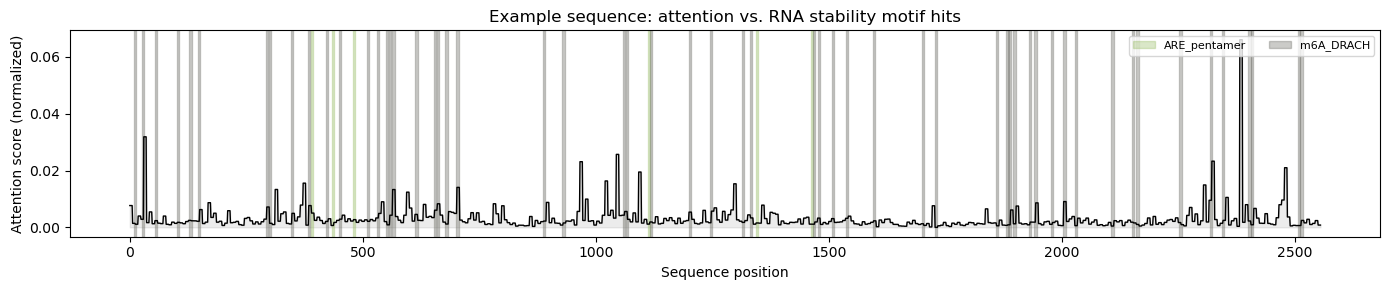

In [ ]:
# Inspect one retained sequence through the attention and motif pipeline.
sample_seq = kept_seqs[0]
rna_dna_seq = rna_to_dna(sample_seq)

attentions, tokens = get_attention_maps(
    rna_model_attn, rna_tok, rna_dna_seq, device=DEVICE
)
attn_score_tokens = aggregate_attention(attentions, layer=-1, mode="incoming")
attn_score = expand_token_attention_to_nucleotides(attn_score_tokens, tokens)

motif_hits = scan_sequence_for_motifs(sample_seq)
print(f"Found {len(motif_hits)} motif hits in this sequence, sequence length {len(sample_seq)}, attention array length {len(attn_score)}")

result = attention_motif_overlap(attn_score, motif_hits)
print(result)

plot_attention_with_motifs(
    attn_score,
    motif_hits,
    title="Example sequence: attention vs. RNA stability motif hits",
)


The saved example contains 63 candidate ARE-pentamer or DRACH matches, covering 311 of 2,556 positions. Its sequence and expanded attention-array lengths are both 2,556. Mean attention is approximately $0.0031$ at matched positions and $0.0033$ elsewhere, with nominal one-sided $p=0.603$.

The ARE-pentamer mask covers 30 positions (nominal $p=0.96$), and the DRACH mask covers 284 (nominal $p=0.43$). Masks can overlap, so per-pattern counts need not sum to the pooled count. The matched-position mean is not higher in this example under the current aggregation. This does not establish a biological null: the patterns are candidate annotations, and the positional test has the dependence and calibration limitations described above. The plot displays the same exploratory comparison.


In [ ]:
overlap_results = []
for seq in kept_seqs[:100]:
    dna_seq = rna_to_dna(seq)
    attentions, tokens = get_attention_maps(
        rna_model_attn, rna_tok, dna_seq, device=DEVICE
    )
    attn_tokens = aggregate_attention(attentions, layer=-1, mode="incoming")
    attn = expand_token_attention_to_nucleotides(attn_tokens, tokens)
    hits = scan_sequence_for_motifs(seq)
    r = attention_motif_overlap(attn, hits)
    if r is not None:
        overlap_results.append(r)

# Summarize nominal threshold crossings and per-sequence descriptive gaps.
sig_fraction = (
    sum(r["p_value"] < 0.05 for r in overlap_results) / len(overlap_results)
)
mean_gap = np.mean([
    r["mean_attention_at_motifs"] - r["mean_attention_elsewhere"]
    for r in overlap_results
])
print(f"Sequences with usable motif hits: {len(overlap_results)} of 100")
print(f"Fraction with significantly higher attention at motif positions (p < 0.05): {sig_fraction:.2f}")
print(f"Mean attention gap (at motifs minus elsewhere): {mean_gap:.4f}")

# Report each candidate pattern separately; the usable sequence sets can differ.
for motif_name in STABILITY_MOTIFS:
    per_motif = [
        r["by_motif"][motif_name]
        for r in overlap_results
        if r["by_motif"].get(motif_name) is not None
    ]
    if not per_motif:
        print(f"{motif_name}: no usable hits across these 100 sequences")
        continue
    sig = sum(m["p_value"] < 0.05 for m in per_motif) / len(per_motif)
    gap = np.mean([
        m["mean_attention_at_motifs"] - m["mean_attention_elsewhere"]
        for m in per_motif
    ])
    print(f"{motif_name}: {len(per_motif)} sequences with hits, {sig:.2f} significant fraction, mean gap {gap:.4f}")


Sequences with usable motif hits: 100 of 100
Fraction with significantly higher attention at motif positions (p < 0.05): 0.07
Mean attention gap (at motifs minus elsewhere): -0.0009
ARE_pentamer: 41 sequences with hits, 0.05 significant fraction, mean gap -0.0027
ARE_nonamer: no usable hits across these 100 sequences
m6A_DRACH: 100 sequences with hits, 0.08 significant fraction, mean gap -0.0009


All 100 sequences in the saved run have an available pooled comparison. The summaries are:

| Pattern set | Sequences with usable comparisons | Fraction with nominal $p<0.05$ | Mean attention gap (matched minus other positions) |
|---|---:|---:|---:|
| Pooled patterns | 100 | 7% | −0.0009 |
| ARE pentamer | 41 | 5% | −0.0027 |
| ARE nonamer | 0 | Not available | Not available |
| DRACH | 100 | 8% | −0.0009 |

These summaries show no positive average attention gap for the evaluated pattern sets. The 7% threshold fraction cannot be treated as a calibrated comparison with a 5% chance rate: positional dependence, repeated token scores, overlapping patterns, and multiple tests remain unaddressed. The saved output reports no usable nonamer hits, so that pattern provides no evaluated comparison in this sample.

The evidence is limited to these candidate patterns, these sequences, and this attention summary. It does not establish absence of regulatory knowledge or a validated absence of enrichment. Verifying sequence-region coverage, using experimentally supported sites, and defining a suitable null comparison remain possible follow-up decisions.


#### Sample-level alignment and prediction error

This diagnostic asks whether examples whose RNA and protein representations are more similar also tend to be easier to predict. It is an **exploratory sample-level adaptation** inspired by [Tjandrasuwita et al. (ICML 2025), Sections 5–6](https://proceedings.mlr.press/v267/tjandrasuwita25a.html). The paper studies relationships across models/configurations and a contrastive-training intervention; this code compares examples from one fixed encoder pair. It does not reproduce those experiments.

The later call supplies `rna_test_c`, `prot_test_c`, and `labels[test_idx]`: paired CCA coordinates and stability labels from the earlier CCA test subset. Corresponding rows must identify the same examples. The encoder weights and the earlier fitted PCA/CCA transformations remain fixed here; the new models fitted in this diagnostic are ordinary linear regressions.

**1. Compare the directions of each example's paired CCA vectors.**

For nonzero vectors, cosine similarity is:

$$
c_i = \frac{\mathbf u_i^\top\mathbf v_i}
{\|\mathbf u_i\|_2\,\|\mathbf v_i\|_2}.
$$

In this notation:

- $n$ is the number of paired examples supplied to this diagnostic; each input coordinate matrix has shape `(n, d)`.
- $i$ identifies one example, from 1 through $n$ in the equations. Python indexes those rows from 0 through `n - 1`.
- $d$ is the number of CCA coordinates per vector, currently 10.
- $\mathbf u_i$ and $\mathbf v_i$ are the RNA and protein vectors for example $i$. Bold symbols denote vectors; each has $d$ coordinates. The mathematics treats them as column vectors even though the NumPy matrices store examples in rows.
- $\top$ means transpose: it turns the mathematical column $\mathbf u_i$ into a row so that $\mathbf u_i^\top\mathbf v_i$ is a dot product. This multiplies corresponding coordinates and sums those products, giving one scalar.
- $\|\mathbf u_i\|_2$ and $\|\mathbf v_i\|_2$ are Euclidean lengths: square the coordinates, add them, and take the square root. The subscript 2 names the norm, not the number of coordinates.
- $c_i$ is one cosine score, between $-1$ and $1$ for nonzero vectors. A larger value means their directions are more similar in the fitted CCA coordinates. It is a chosen per-example alignment score, not a biological measurement.

The notebook delegates this calculation to [scikit-learn's `cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html). Each `i:i+1` slice retains shape `(1, d)`; the resulting `(1, 1)` similarity matrix contains one score, selected by `[0, 0]`. The displayed ratio is undefined for a zero vector, whereas the library returns zero for a comparison involving a zero vector; that value does not define its direction.

**2. Combine the coordinates and obtain an error from a model that did not train on that row.**

Concatenation appends the protein coordinates after the RNA coordinates:

$$
\mathbf z_i = [\mathbf u_i;\mathbf v_i].
$$

In this notation:

- $\mathbf z_i$ is the combined feature vector for example $i$, with $2d$ coordinates, currently 20.
- The brackets and semicolon mean to append the two vectors' coordinates in the stated order. They do not average or multiply the vectors.
- The NumPy array `fused` stores these combined vectors as rows, with shape `(n, 2d)`.

The code divides these $n$ examples into five shuffled folds using `SEED`. For each fold, scikit-learn's `LinearRegression().fit(...)` fits an intercept and coefficients on the other folds by ordinary least squares. Its `.predict(...)` call predicts the held-out fold. The notebook then calculates each row's absolute error:

$$
e_i = \left|y_i - \hat f_{-F(i)}(\mathbf z_i)\right|.
$$

In this notation:

- $y_i$ is the observed stability label for example $i$, a scalar.
- $F(i)$ identifies the set of rows in the held-out regression fold containing example $i$.
- $\hat f_{-F(i)}$ is the regression predictor fitted using all the other folds. The hat marks a fitted predictor; the subscript $-F(i)$ means that this fold was excluded from fitting, not that a negative function was calculated.
- $\hat f_{-F(i)}(\mathbf z_i)$ is the scalar prediction obtained by giving that predictor the combined vector for row $i$.
- $e_i$ is the absolute prediction error. The single vertical bars mean absolute value: predictions equally far above and below the observed label have equal error. They are different from the double bars used for vector norms above.

The mathematical name $\hat f_{-F(i)}$ describes each fitted `reg` object; there is no Python function with that name. This diagnostic fits its regression folds within the earlier CCA test subset. Those rows were held out when PCA and CCA were fitted, and each is held out again from its own regression fit. No PCA or CCA refitting occurs inside the regression loop.

**3. Relate alignment ranks to error ranks.**

$$
\rho_s = \operatorname{corr}\!\left(
\operatorname{rank}(\mathbf c),\operatorname{rank}(\mathbf e)
\right).
$$

In this notation:

- $\mathbf c$ collects the $n$ scores $c_i$ in row order, stored as `local_alignment` with shape `(n,)`.
- $\mathbf e$ collects the matching $n$ errors $e_i$, stored as `errors` with shape `(n,)`.
- $\operatorname{rank}$ replaces values by their positions when sorted from smallest to largest, retaining the original row order. Ties receive their average rank; for example, values `(4, 4, 9)` have ranks `(1.5, 1.5, 3)`.
- $\operatorname{corr}$ denotes Pearson correlation between the two rank vectors. Applying it to ranks produces Spearman correlation.
- $\rho_s$, read as "rho sub s," is the resulting scalar Spearman coefficient; the subscript identifies the rank-correlation statistic.

SciPy's [`spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) performs the ranking and correlation and returns a coefficient and nominal p-value. The notebook does not separately create rank arrays. If all alignment scores or all errors are equal, their rank correlation is undefined; SciPy returns `NaN` with a constant-input warning. A negative coefficient means higher alignment tends to accompany smaller errors; a near-zero coefficient indicates little rank association in this sample. The function retains `slope` in its existing name for compatibility, but it does not fit or return a regression slope between alignment and error.

**Small worked illustration.** Suppose three examples have cosine scores `(0.2, 0.5, 0.9)` and held-out absolute errors `(0.8, 0.4, 0.1)`. Their ranks are `(1, 2, 3)` and `(3, 2, 1)`, so the Spearman coefficient is $-1$: higher alignment accompanies lower error in this illustrative ordering. These are invented scores, not a three-row execution of the five-fold procedure.

The earlier CCA split and these regression folds operate on rows, without the sequence grouping used by the Track A probes. Shared fitted transformations, overlapping training folds, and repeated sequences limit a simple independent-observation interpretation of the p-value. No result here estimates the effect of training with an alignment loss or establishes modality uniqueness; those questions require separate controlled comparisons.


In [ ]:
def compute_alignment_performance_slope(rna_cca, protein_cca, stability_labels, n_folds=5):
    """Correlate sample-level CCA cosine similarity with out-of-fold error.

    Inputs are paired CCA-projected rows and their matching stability labels.
    This exploratory rank association adapts the paper's motivation; it is
    not its across-model alignment-performance slope or an alignment-loss test.
    """
    # Compare paired rows in the existing CCA coordinate system.
    local_alignment = np.array([
        cosine_similarity(rna_cca[i:i+1], protein_cca[i:i+1])[0, 0]
        for i in range(len(stability_labels))
    ])

    # Fit ordinary linear regression and collect held-out absolute errors.
    fused = np.concatenate([rna_cca, protein_cca], axis=1)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    errors = np.zeros(len(stability_labels))
    for train_idx, test_idx in kf.split(fused):
        reg = LinearRegression().fit(fused[train_idx], stability_labels[train_idx])
        errors[test_idx] = np.abs(reg.predict(fused[test_idx]) - stability_labels[test_idx])

    # This is a rank correlation, despite the retained variable/function names.
    slope_corr, p_value = spearmanr(local_alignment, errors)
    return {
        "spearman_corr_alignment_vs_error": slope_corr,
        "p_value": p_value,
        "interpretation": (
            "A negative correlation associates higher sample-level alignment "
            "with lower prediction error under this procedure. A near-zero "
            "value indicates no detected monotonic association. This "
            "exploratory adaptation does not establish modality uniqueness "
            "or predict the effect of training with an alignment loss."
        )
    }

#### Representational similarity analysis

Representational similarity analysis (RSA) asks whether pairs of examples that are dissimilar within one representation also tend to be dissimilar within the other. The later call supplies the original paired final-layer matrices, `rna_embeds` and `prot_embeds`, rather than the CCA projections. Corresponding rows must identify the same examples in the same order; the feature counts can differ. This diagnostic fits no predictor or projection.

**1. Center each example across its own features.**

For one RNA embedding, first find its mean feature value:

$$
\bar x_i = \frac{1}{p}\sum_{k=1}^{p}x_{ik}.
$$

In this notation:

- $X$ is the RNA embedding matrix with shape `(n, p)`; $Y$ is the protein embedding matrix with shape `(n, q)`.
- $n$ is the number of paired examples, while $p$ and $q$ are the RNA and protein feature counts. The latter may differ.
- $i$ identifies an example row, from 1 through $n$ in the equations. Python indexes those same rows from 0 through `n - 1`.
- $k$ identifies an RNA feature, from 1 through $p$; $x_{ik}$ is the scalar value of feature $k$ in example $i$. Python feature indices begin at 0.
- $\bar x_i$, read as "x bar sub i," is the mean of the feature values within row $i$, a scalar. The bar marks that average.
- $\sum_{k=1}^{p}$ adds this row's $p$ feature values, and dividing by $p$ takes their mean.

Subtract that mean from every coordinate of the row:

$$
\widetilde{\mathbf x}_i
= \mathbf x_i - \bar x_i\mathbf 1_p.
$$

In this notation:

- $\mathbf x_i$ is the full RNA embedding vector for example $i$, with $p$ coordinates. Bold symbols denote vectors.
- $\mathbf 1_p$ is a vector of $p$ ones. Multiplying it by the scalar $\bar x_i$ gives a vector with that mean in every coordinate.
- $\widetilde{\mathbf x}_i$, read as "x tilde sub i," is the centered row vector; the tilde distinguishes it from the original embedding. Its length is still $p$ coordinates.
- The subtraction acts coordinate by coordinate. It centers each row across its features, unlike CKA's centering of each feature across example rows.

The same construction applies to a protein row using its own $q$ coordinates and its own mean. These are explanatory intermediate quantities for the correlation-distance calculation inside SciPy; the notebook does not create variables named `x_bar` or `x_tilde`.

**2. Calculate the correlation distance between two rows of the same representation.**

$$
d_X(i,j)
= 1 - \frac{\widetilde{\mathbf x}_i^\top\widetilde{\mathbf x}_j}
{\|\widetilde{\mathbf x}_i\|_2\,\|\widetilde{\mathbf x}_j\|_2}.
$$

In this notation:

- $i$ and $j$ identify two different examples in $X$; each vector has the same $p$ features within this representation.
- $d_X(i,j)$ is their scalar correlation distance. The subscript $X$ names the representation being compared, and the parentheses identify the pair of rows.
- $\top$ means transpose. Treating the mathematical vectors as columns, it turns the first vector into a row so their product is a dot product: multiply corresponding coordinates and sum the products.
- $\|\cdot\|_2$ is Euclidean length: square the vector's coordinates, sum those squares, and take the square root. The subscript 2 identifies the norm.
- The fraction is the Pearson correlation of the two original feature profiles, calculated by normalizing the centered dot product. Subtracting it from 1 changes similarity into distance.

Correlation 1 gives distance 0, correlation 0 gives distance 1, and correlation $-1$ gives distance 2. A row whose features are all identical becomes a zero vector after centering, making this distance undefined. The helper adds no special handling for that case. See [SciPy's definition](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.correlation.html). Applying the same calculation within $Y$ gives $d_Y(i,j)$, using its $q$ features; no individual RNA feature is matched to an individual protein feature.

**3. Collect matching pairs and compare their distance rankings.**

Each representation contributes one distance for every unordered pair of distinct examples. The number of pairs is:

$$
M = \frac{n(n-1)}{2}.
$$

In this notation:

- $M$ is the number of distances in each comparison vector.
- There are $n$ choices for the first example and $n-1$ other examples. Dividing by 2 removes the reversed duplicate of every pair.
- Keeping only $i<j$ selects each distinct pair once and excludes comparisons of a row with itself. For $n=3$, the order is $(1,2)$, $(1,3)$, $(2,3)$; Python labels those pairs `(0, 1)`, `(0, 2)`, `(1, 2)`.

SciPy's [`pdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html) returns these values as a one-dimensional condensed distance vector, rather than a square distance matrix. Because the input rows correspond, the RNA and protein vectors use matching pair order. For the saved 981-row input, each vector contains 480,690 pair distances; those distances are not 480,690 independent examples.

The final statistic compares the ranks of the two distance vectors:

$$
\rho_{\mathrm{RSA}}
= \operatorname{corr}\!\left(
\operatorname{rank}(\mathbf d_X),
\operatorname{rank}(\mathbf d_Y)
\right).
$$

In this notation:

- $\mathbf d_X$ and $\mathbf d_Y$ are the RNA and protein distance vectors, each with $M$ scalar entries in matching pair order. The code names them `dist_a` and `dist_b`.
- $\operatorname{rank}$ assigns positions from smallest to largest distance, retaining the original pair order and assigning tied distances their average rank.
- $\operatorname{corr}$ denotes Pearson correlation of those rank vectors, which is Spearman correlation.
- $\rho_{\mathrm{RSA}}$, read as "rho sub RSA," is the resulting scalar coefficient. The subscript labels this RSA statistic.

If either distance vector is constant, the rank correlation is undefined and SciPy returns `NaN` with a constant-input warning. This is distinct from a single constant feature profile making its pair distances undefined. A positive coefficient indicates agreement in which pairs are more or less dissimilar. It describes geometry; it does not identify a particular shared subspace or biological mechanism.

**Connection to the code.** `compute_rsa` is the notebook's wrapper around three library calls. The equations explain those library calculations; the notebook contains no handwritten centering, distance, or ranking implementation.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `pdist(embeddings_a, metric="correlation")` | `(n, p)` → `(M,)` | Calculate RNA correlation distances for each distinct pair, producing $\mathbf d_X$. |
| `pdist(embeddings_b, metric="correlation")` | `(n, q)` → `(M,)` | Calculate protein distances for the same pairs, producing $\mathbf d_Y$. |
| `spearmanr(dist_a, dist_b)` | Two `(M,)` arrays → two scalar results | Rank each distance vector and return their Spearman coefficient and nominal p-value. |

**Small worked illustration.** RNA rows `(1, 2, 3)` and `(2, 4, 6)` have means 2 and 4. Their centered profiles are `(-1, 0, 1)` and `(-2, 0, 2)`: identical directions with different magnitudes, giving correlation 1 and distance 0. Adding a third row `(3, 2, 1)` gives the opposite centered direction, so the RNA pair distances are `(0, 2, 2)`. If the corresponding protein distances are `(0.1, 0.9, 0.9)`, both distance vectors have ranks `(1, 2.5, 2.5)` and RSA is 1. This illustrates agreement in distance rankings without equality of distance values; these are invented numbers, not encoder outputs.

Pairwise distances share examples, so their entries are statistically dependent. The default Spearman p-value is therefore a nominal summary, not a calibrated significance test for this geometry comparison. RSA also reuses embeddings examined by the earlier metrics, so it is not independent confirmation of their conclusions.


In [ ]:
def compute_rsa(embeddings_a, embeddings_b):
    """Compare matched pairwise correlation distances using Spearman correlation."""
    dist_a = pdist(embeddings_a, metric="correlation")
    dist_b = pdist(embeddings_b, metric="correlation")
    return spearmanr(dist_a, dist_b)

#### Run and interpret the alignment diagnostics

The two calls below use different representations and sets of rows:

| Diagnostic | Inputs | Reported quantity |
|---|---|---|
| Alignment and prediction error | Held-out CCA vectors `rna_test_c` and `prot_test_c`, with the corresponding `labels[test_idx]` | Spearman association between per-example cosine similarity and out-of-fold absolute error |
| RSA | All paired final-layer embeddings, `rna_embeds` and `prot_embeds` | Spearman agreement between within-modality pairwise-distance rankings |

The first diagnostic fits its regression folds inside the earlier CCA test subset; that subset was held out when PCA and CCA were fitted. This distinction matters: the same phrase "held out" refers to two different fitting steps. The second diagnostic fits no predictor. Both results summarize the existing procedure and do not select an alignment objective for the next stage.

In [ ]:
slope_result = compute_alignment_performance_slope(rna_test_c, prot_test_c, labels[test_idx])
print(slope_result)

rsa_score, rsa_pval = compute_rsa(rna_embeds, prot_embeds)
print(f"RSA (Spearman correlation of distance structures): {rsa_score:.3f}, p = {rsa_pval:.4g}")

{'spearman_corr_alignment_vs_error': -0.012889959728224883, 'p_value': 0.8255117133708139, 'interpretation': 'A negative correlation associates higher sample-level alignment with lower prediction error under this procedure. A near-zero value indicates no detected monotonic association. This exploratory adaptation does not establish modality uniqueness or predict the effect of training with an alignment loss.'}
RSA (Spearman correlation of distance structures): 0.234, p = 0


**Saved results.** These values come from the notebook's existing output; the readability pass has not rerun the analyses.

| Diagnostic | Spearman coefficient | Nominal p-value |
|---|---:|---:|
| Per-example alignment versus prediction error | $-0.013$ | $0.83$ |
| RNA versus protein pairwise-distance rankings (RSA) | $0.234$ | Printed as `0`; interpret cautiously |

The alignment/error coefficient is close to zero, and this procedure did not detect a monotonic association. It does not establish absence of every relationship, high modality uniqueness, or whether an alignment loss would help or hurt. It is also not the paper's across-model slope. The diagnostic uses the 295 rows in the saved CCA test subset; [SciPy's Spearman documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) also cautions about the default p-value approximation for smaller samples. That limitation adds to the shared-model and repeated-sequence issues already described.

The positive RSA coefficient describes modest agreement between distance rankings. Its printed p-value is a numerical output, not evidence of literally zero probability. More fundamentally, the shared examples in the distance vectors prevent treating the default p-value as an independent-observation significance test. A suitable permutation or other dependence-aware analysis would be a separate methodological change.

Together with the predictive probes, geometry comparisons and attention summaries, these diagnostics describe selected properties of the current frozen representations. They leave the alignment objective and fusion design open. Reviewing the biological meaning, evaluation limitations and appropriate controlled comparisons remains necessary before treating the pilot as a completed scientific argument.

- Check esm encoder where it can be part of the similarity in the embedding space where it can be in direction of low and high variance, pca could be applicable here
- hyena couple model; good for very long sequence
- start to use same model in bio lang and use same model they use in alignment since they argue about tokenization.
- sometimes i need to put these together to see which correlation is being shown for a more comprehensive analysis using some of the simpler fusion methods from bioLang with many pre-trained models
- think of some biological use cases, but keep in general
- if there are 3 RNA based models can they be used together since they are trained on different datasets
- DNA and mRNA has huge overlap information wise, so an experiment is surrounding mRNA and proteins
- one thing really want: overleaf project, create GitHub, share it with Mina
- next meeting is october 5th or 7th